在之前的尝试中,我能想到的符合直觉的模型,都无法进一步的提高模型,反而是我自己构建的因子,可能学到了过多的噪声,反而在实际预测中表现很差.此外,我没有考虑到非线性的问题,只用了线性模型和宏观变量来解释,对于股价的突变无法解释.在考虑到新增数据前,再次回到简单模型,让模型自行挖掘可能存在的关系.  
因此,我在这个地方尝试用神经网络模型.  
以下内容由Codex生成,进行学习.

# 1 先回到原来的七个数据
这次先只改变模型。读取之前保存的 `Dataset.pkl`，仍然用七个因子的**水平值**解释紫金股价，不增加技术指标、交互项，也不改成涨跌幅。

保留原来的 `X`、`Y`、`X_train`、`Y_train` 命名，以及“文字解释 → 一小段代码 → 观察结果”的方式。

先提出问题：**同样的数据，小型神经网络能不能比线性模型解释得更好？**

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("当前 Python：", sys.executable)
print("PyTorch：", torch.__version__)
# 这个网络很小，先用 CPU，方便重复实验，也不必切换环境。
device = torch.device('cpu')
torch.set_num_threads(1)
SEED = 42
HIDDEN = 8
LR = 0.01
MAX_EPOCHS = 2000
PATIENCE = 150


Matplotlib is building the font cache; this may take a moment.


当前 Python： /opt/anaconda3/bin/python3
PyTorch： 2.14.0


In [2]:
# 无论从项目根目录还是 Notebook 所在目录启动，都能找到数据。
candidates = [Path.cwd(), *Path.cwd().parents, Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-')]
PROJECT_ROOT = next(p for p in candidates if (p / 'src/pickle/Dataset.pkl').exists())
Dataset = pd.read_pickle(PROJECT_ROOT / 'src/pickle/Dataset.pkl')
X = Dataset['X'].copy()
Y = Dataset['Y'].copy()
expected = ['A_500', 'Dollar Index', 'cn_10y_rate', 'us_10y_rate',
            'brent', 'Copper Futures Price', 'Gold Futures Price']
assert list(X.columns) == expected, '请检查是否还是原来的七个变量'
assert X.index.equals(Y.index)
assert X.index.is_monotonic_increasing and X.index.is_unique
assert np.isfinite(X.to_numpy()).all() and np.isfinite(Y.to_numpy()).all()
display(X.head())
print('样本数量：', len(X))


,A_500,Dollar Index,cn_10y_rate,us_10y_rate,brent,Copper Futures Price,Gold Futures Price
2012-05-09,1000.000000,80.080002,3.5414,1.87,111.89,3.6595,1000.000000
2012-05-10,1000.166229,80.110001,3.5287,1.89,112.24,3.6905,1000.878474
2012-05-11,993.645535,80.279999,3.4907,1.84,112.50,3.6480,993.662561
2012-05-14,986.340876,80.599998,3.4461,1.78,110.79,3.5540,979.230736
2012-05-15,986.907436,81.220001,3.4050,1.76,111.40,3.5175,976.846393


样本数量： 3837


# 2 训练集和测试集保持一致
仍然是前面的数据训练，最后 **500 条记录**测试；不随机打乱，也不重新删除日期。

在训练集内部，暂时留出最后 20% 作为验证集，用它选择训练轮数。确定轮数后，重新初始化网络，在**全部原训练集**上训练；最终测试集不参与轮数或结构选择。

In [3]:
X_train, X_test = X.iloc[:-500].copy(), X.iloc[-500:].copy()
Y_train, Y_test = Y.iloc[:-500].copy(), Y.iloc[-500:].copy()
cut = int(len(X_train) * 0.8)
X_fit, X_val = X_train.iloc[:cut], X_train.iloc[cut:]
Y_fit, Y_val = Y_train.iloc[:cut], Y_train.iloc[cut:]
assert X_train.index.max() < X_test.index.min()
split_info = pd.DataFrame([
    [name, len(data), data.index.min(), data.index.max()]
    for name, data in [('完整训练集', X_train), ('内部拟合集', X_fit),
                       ('内部验证集', X_val), ('最终测试集', X_test)]
], columns=['数据段', '记录数', '开始日期', '结束日期'])
display(split_info)


,数据段,记录数,开始日期,结束日期
0,完整训练集,3337,2012-05-09,2024-09-13
1,内部拟合集,2669,2012-05-09,2022-04-05
2,内部验证集,668,2022-04-06,2024-09-13
3,最终测试集,500,2024-09-14,2026-07-23


# 3 从 7 → 8 → 1 开始
`7` 是输入因子数量；`8` 是自己设定的隐藏层神经元数量；`1` 是输出一个股价。

每个隐藏神经元先学一个类似多元回归的组合，再经过 `ReLU(z)=max(0,z)`。这个转折让不同输入区域可以有不同关系；没有激活函数，连续的线性层仍然可以合并成一个线性模型。

`8` 不是八种股票，也不是八类数据，而是允许模型学习八个隐藏组合。这些组合不一定能直接命名为某个经济含义。整个网络只有 **73 个可训练参数**：`7×8 + 8 + 8×1 + 1`。

输出层不放 ReLU，因为我们会标准化股价，标准化后的值可以小于零。

In [4]:
def build_mlp(seed=SEED):
    torch.manual_seed(seed)
    return nn.Sequential(
        nn.Linear(7, HIDDEN),  # 七个原始因子 → 八个组合
        nn.ReLU(),            # 加入非线性
        nn.Linear(HIDDEN, 1)  # 八个组合 → 一个股价
    ).to(device)

model = build_mlp()
print(model)
print('参数数量：', sum(p.numel() for p in model.parameters()))


Sequential(
  (0): Linear(in_features=7, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)
参数数量： 73


# 4 先标准化，再转换为 Tensor
Tensor 可以先理解为 PyTorch 使用的数值数组。输入形状为 `(样本数, 7)`，目标为 `(样本数, 1)`，二者必须逐行对应。

美元、利率、黄金的量纲不同，先标准化更容易训练。股价也标准化，让优化过程更稳定；最后要还原为原股价单位再计算 RMSE 和 R²。

此时标准化器只用内部拟合集来 `fit`，验证集只 `transform`。否则验证期的信息会提前进入模型。

In [5]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_fit_scaled = scaler_x.fit_transform(X_fit)
X_val_scaled = scaler_x.transform(X_val)
Y_fit_scaled = scaler_y.fit_transform(Y_fit.to_numpy().reshape(-1, 1))
Y_val_scaled = scaler_y.transform(Y_val.to_numpy().reshape(-1, 1))

def to_tensor(values):
    return torch.tensor(np.asarray(values), dtype=torch.float32, device=device)

X_fit_tensor = to_tensor(X_fit_scaled)
Y_fit_tensor = to_tensor(Y_fit_scaled)
X_val_tensor = to_tensor(X_val_scaled)
Y_val_tensor = to_tensor(Y_val_scaled)
print(X_fit_tensor.shape, Y_fit_tensor.shape)


torch.Size([2669, 7]) torch.Size([2669, 1])


# 5 神经网络到底怎么学习？
一个 epoch 是完整看一遍拟合数据。这个小模型先用全部拟合样本一起计算，不引入分批训练。

每轮按下面顺序做：
1. `model(X)`：根据当前参数预测。
2. `loss_fn`：用 MSE 衡量预测与真实值的差距。
3. `zero_grad()`：清除上轮梯度。
4. `loss.backward()`：计算每个参数应该往哪个方向调整。
5. `optimizer.step()`：Adam 根据梯度更新参数。

训练用 MSE，报告仍保留 RMSE 和 R²。RMSE 与 MSE 的最小值位置一致，RMSE 的单位更便于解释。

每次更新后检查内部验证误差，连续 150 轮没有改善就停止。这里记录最佳轮数；不是把最后一轮自动当成最好的一轮。

验证集选择的轮数： 29


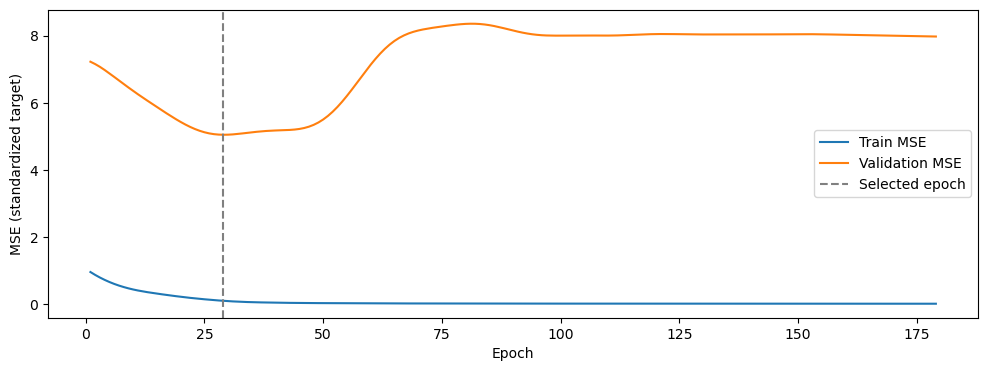

In [6]:
model = build_mlp()
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
history = []
best_val_loss = float('inf')
best_epoch = 1
best_state_cell6 = None
wait = 0

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    prediction = model(X_fit_tensor)
    loss = loss_fn(prediction, Y_fit_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        train_loss = loss_fn(model(X_fit_tensor), Y_fit_tensor).item()
        val_loss = loss_fn(model(X_val_tensor), Y_val_tensor).item()
    assert np.isfinite(train_loss) and np.isfinite(val_loss)
    history.append([epoch, train_loss, val_loss])

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        best_epoch = epoch
        # 克隆权重，避免后续训练原地更新这份最佳快照。
        best_state_cell6 = {name: value.detach().clone()
                            for name, value in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
    if epoch % 200 == 0:
        print(f'Epoch {epoch}：训练 MSE={train_loss:.4f}，验证 MSE={val_loss:.4f}')
    if wait >= PATIENCE:
        break

history = pd.DataFrame(history, columns=['epoch', 'train_mse', 'val_mse'])
print('验证集选择的轮数：', best_epoch)
plt.figure(figsize=(12, 4))
plt.plot(history.epoch, history.train_mse, label='Train MSE')
plt.plot(history.epoch, history.val_mse, label='Validation MSE')
plt.axvline(best_epoch, color='gray', linestyle='--', label='Selected epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE (standardized target)')
plt.legend()
plt.show()


使用 [6] 最后执行的第 179 轮参数；验证集选出的最佳轮数为 29，但 [6] 没有恢复该轮权重。
训练期图包含内部拟合集和验证集；灰色区域是未参与梯度更新的验证段。


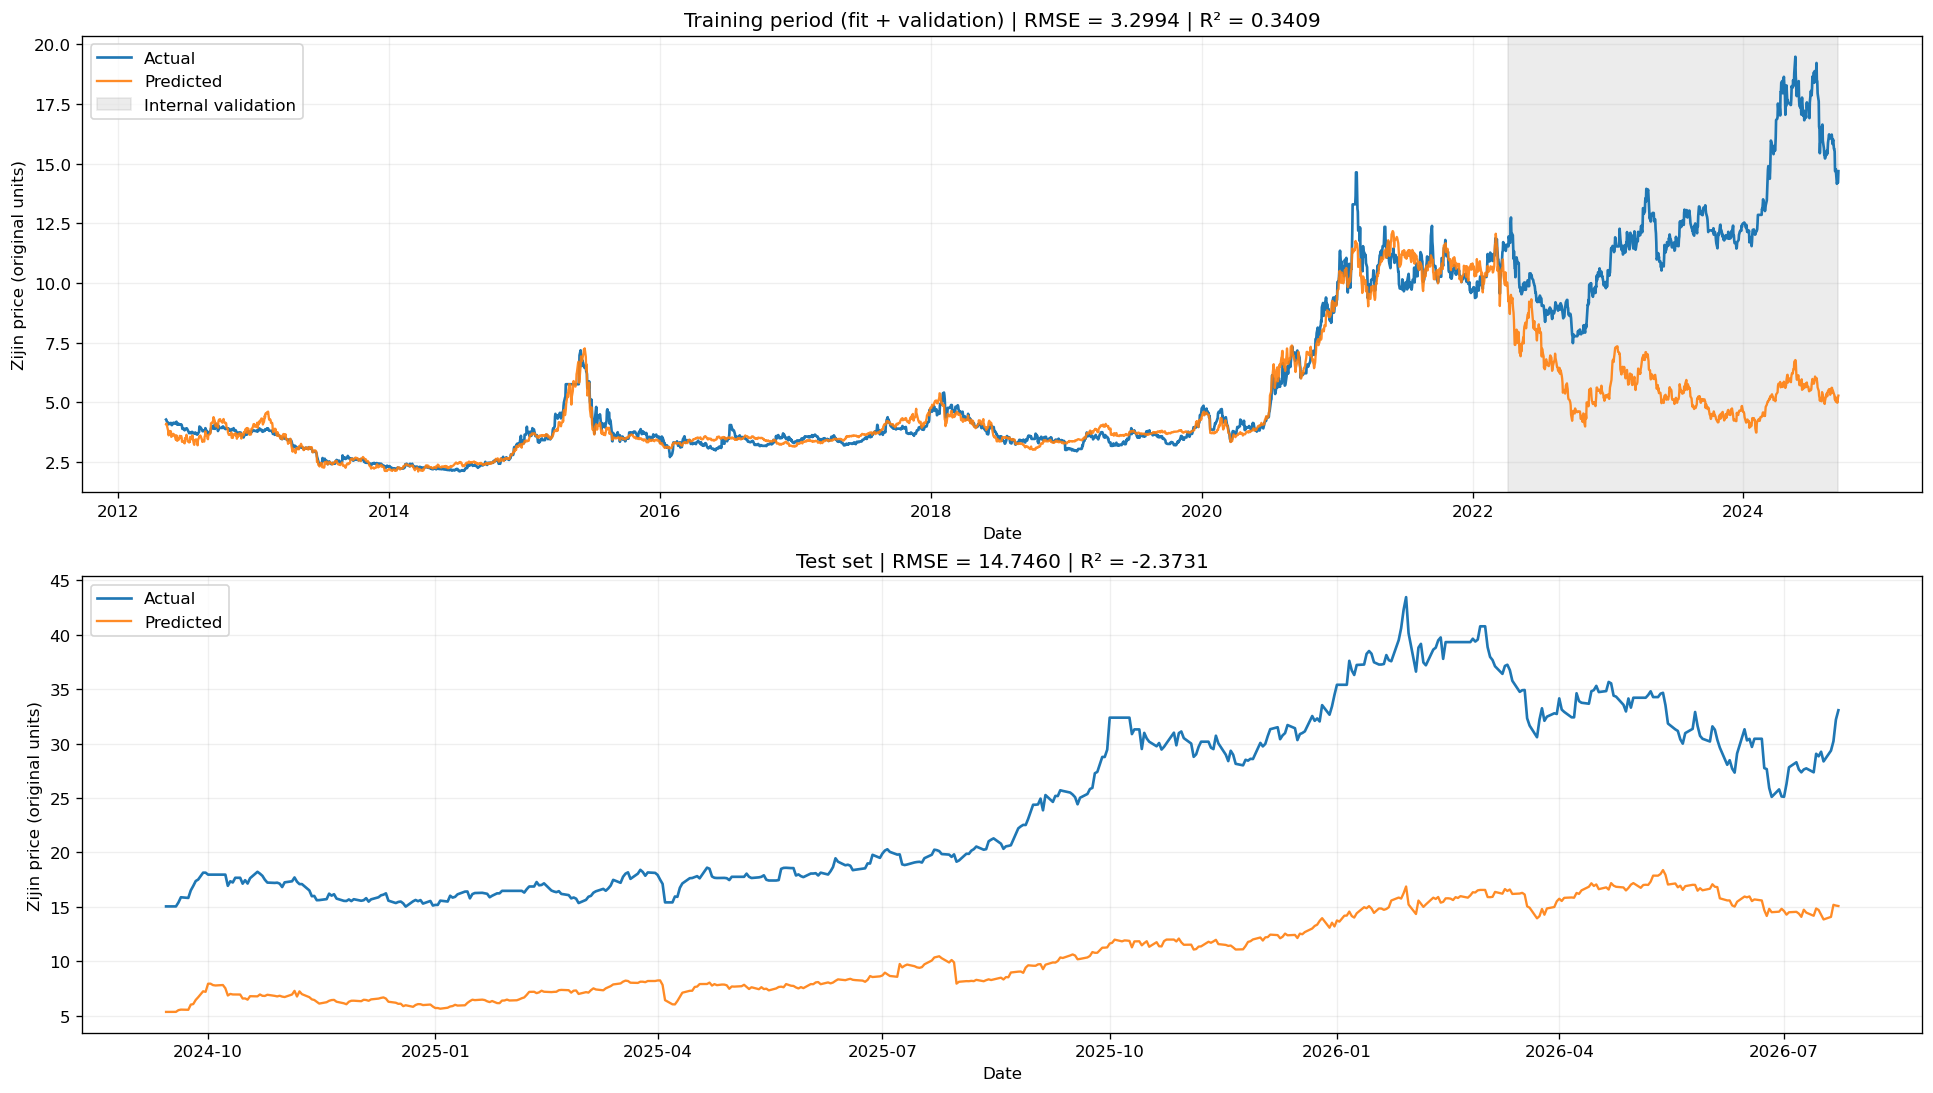

In [ ]:
# 查看 [6] 结束时的模型：未恢复 best_epoch 权重，也未在完整训练集重训。
# 沿用 [5] 仅在 X_fit / Y_fit 上拟合的标准化器，预测还原为原股价单位。
model.eval()
with torch.no_grad():
    pred6_train = scaler_y.inverse_transform(
        model(to_tensor(scaler_x.transform(X_train))).cpu().numpy()
    ).ravel()
    pred6_test = scaler_y.inverse_transform(
        model(to_tensor(scaler_x.transform(X_test))).cpu().numpy()
    ).ravel()

predictions_cell6 = {
    'train': pd.DataFrame({'Actual': np.asarray(Y_train).ravel(),
                           'Predicted': pred6_train}, index=Y_train.index),
    'test': pd.DataFrame({'Actual': np.asarray(Y_test).ravel(),
                          'Predicted': pred6_test}, index=Y_test.index)
}
print(f"使用 [6] 最后执行的第 {int(history.epoch.iloc[-1])} 轮参数；"
      f"验证集选出的最佳轮数为 {best_epoch}，但 [6] 没有恢复该轮权重。")
print('训练期图包含内部拟合集和验证集；灰色区域是未参与梯度更新的验证段。')

fig, axes = plt.subplots(2, 1, figsize=(16, 9), constrained_layout=True)
for ax, key, title in zip(axes, ['train', 'test'],
                         ['Training period (fit + validation)', 'Test set']):
    frame = predictions_cell6[key]
    rmse = np.sqrt(mean_squared_error(frame['Actual'], frame['Predicted']))
    r2 = r2_score(frame['Actual'], frame['Predicted'])
    ax.plot(frame.index, frame['Actual'], label='Actual', color='tab:blue', linewidth=1.6)
    ax.plot(frame.index, frame['Predicted'], label='Predicted', color='tab:orange',
            linewidth=1.4, alpha=0.9)
    if key == 'train':
        ax.axvspan(X_val.index.min(), X_val.index.max(), color='gray', alpha=0.15,
                   label='Internal validation')
    ax.set(title=f'{title} | RMSE = {rmse:.4f} | R² = {r2:.4f}',
           xlabel='Date', ylabel='Zijin price (original units)')
    ax.grid(alpha=0.2)
    ax.legend(loc='upper left')
plt.show()


使用验证集选出的第 29 轮最佳权重。
训练期图包含内部拟合集和验证集；灰色区域是未参与梯度更新的验证段。


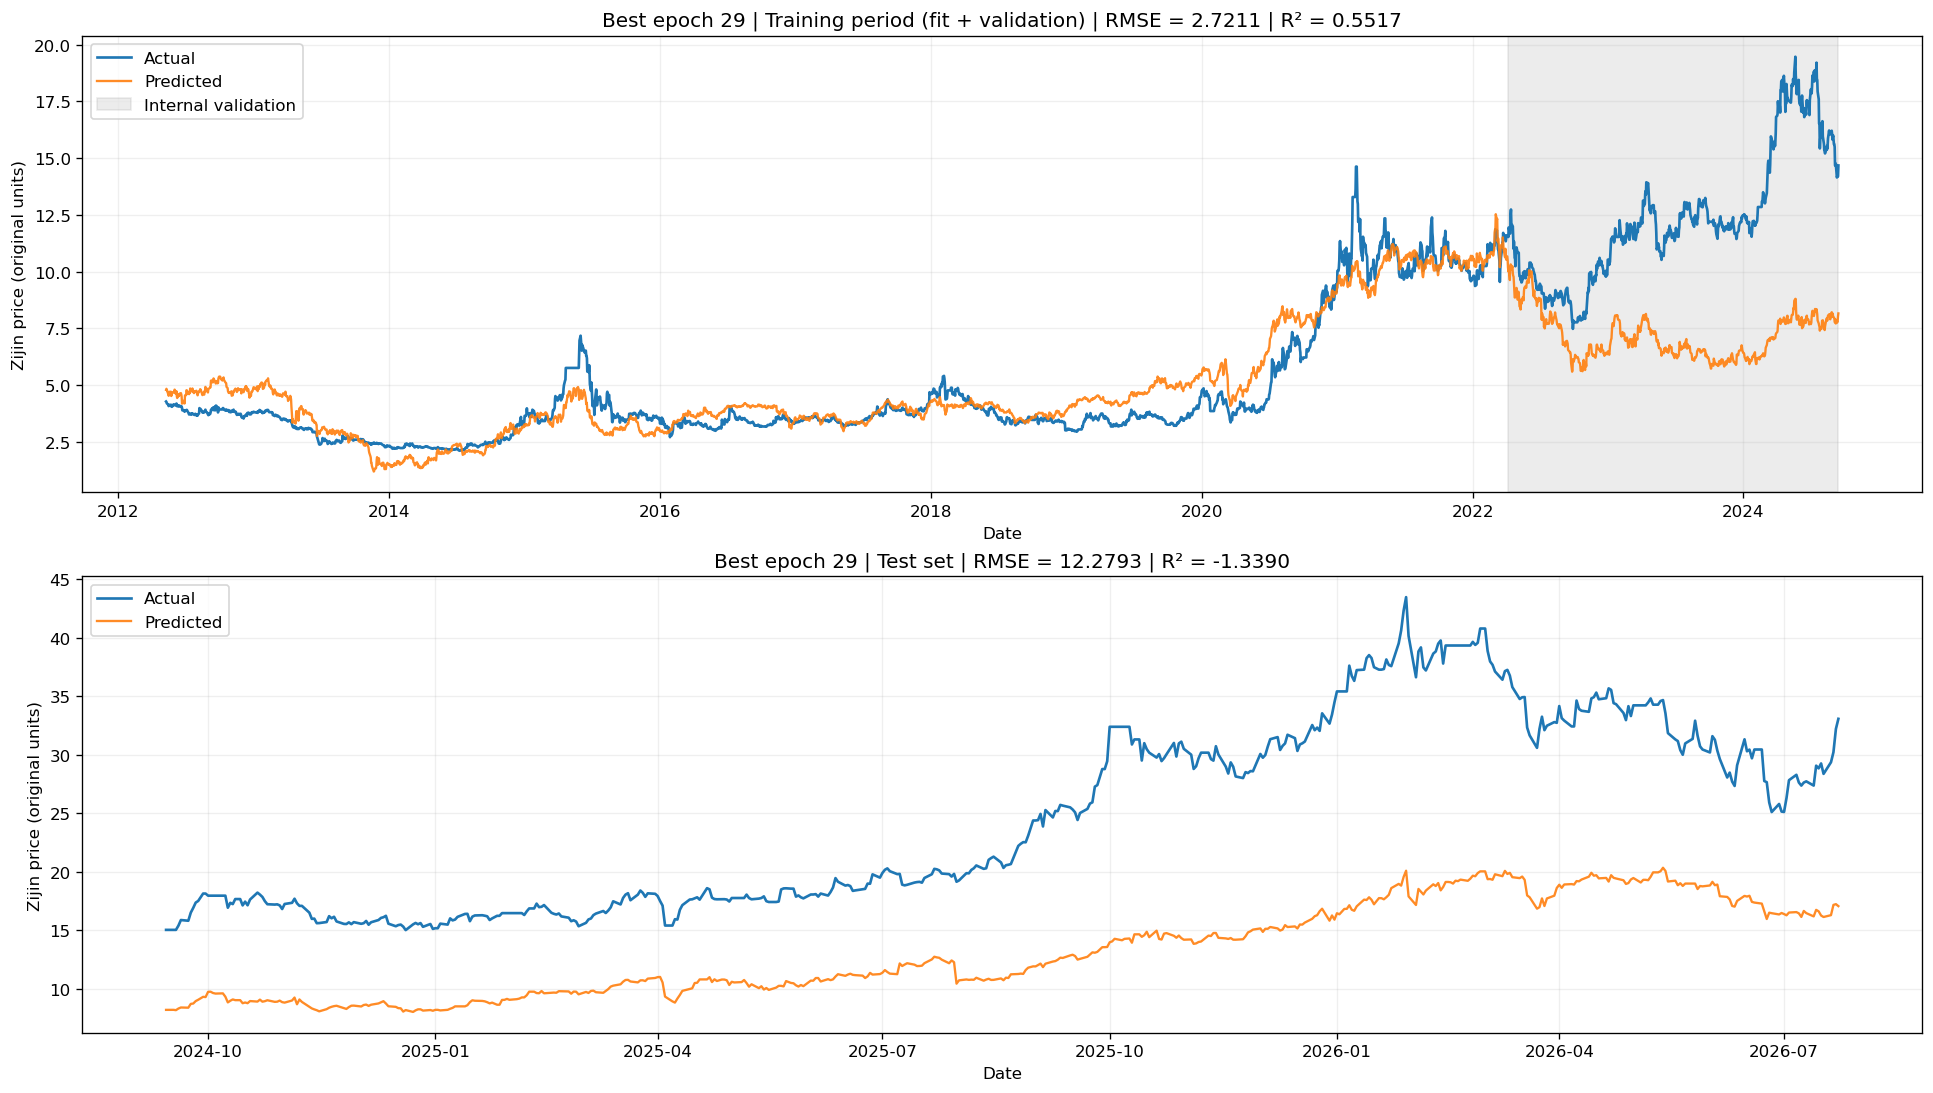

In [ ]:
# 最佳权重对比图：先重新运行上方 [6]，生成 best_state_cell6 快照。
# 复制模型并恢复快照，保留 model 的最后一轮参数用于上一张图。
from copy import deepcopy
model_best_cell6 = deepcopy(model)
model_best_cell6.load_state_dict(best_state_cell6)
model_best_cell6.eval()
with torch.no_grad():
    restored_val_loss = loss_fn(model_best_cell6(X_val_tensor), Y_val_tensor).item()
assert np.isclose(restored_val_loss, best_val_loss), '恢复后的验证误差应与最佳记录一致'

with torch.no_grad():
    pred6_best_train = scaler_y.inverse_transform(
        model_best_cell6(to_tensor(scaler_x.transform(X_train))).cpu().numpy()
    ).ravel()
    pred6_best_test = scaler_y.inverse_transform(
        model_best_cell6(to_tensor(scaler_x.transform(X_test))).cpu().numpy()
    ).ravel()

predictions_best_cell6 = {
    'train': pd.DataFrame({'Actual': np.asarray(Y_train).ravel(),
                           'Predicted': pred6_best_train}, index=Y_train.index),
    'test': pd.DataFrame({'Actual': np.asarray(Y_test).ravel(),
                          'Predicted': pred6_best_test}, index=Y_test.index)
}
print(f'使用验证集选出的第 {best_epoch} 轮最佳权重。')
print('训练期图包含内部拟合集和验证集；灰色区域是未参与梯度更新的验证段。')

fig, axes = plt.subplots(2, 1, figsize=(16, 9), constrained_layout=True)
for ax, key, title in zip(axes, ['train', 'test'],
                         ['Training period (fit + validation)', 'Test set']):
    frame = predictions_best_cell6[key]
    rmse = np.sqrt(mean_squared_error(frame['Actual'], frame['Predicted']))
    r2 = r2_score(frame['Actual'], frame['Predicted'])
    ax.plot(frame.index, frame['Actual'], label='Actual', color='tab:blue', linewidth=1.6)
    ax.plot(frame.index, frame['Predicted'], label='Predicted', color='tab:orange',
            linewidth=1.4, alpha=0.9)
    if key == 'train':
        ax.axvspan(X_val.index.min(), X_val.index.max(), color='gray', alpha=0.15,
                   label='Internal validation')
    ax.set(title=f'Best epoch {best_epoch} | {title} | RMSE = {rmse:.4f} | R² = {r2:.4f}',
           xlabel='Date', ylabel='Zijin price (original units)')
    ax.grid(alpha=0.2)
    ax.legend(loc='upper left')
plt.show()


### 检查输入因子：全数据集的标准化走势

沿用原划分，只使用内部拟合集 `X_fit` 的均值和标准差，转换完整数据集 `X`。

- 蓝线、白色背景：内部拟合集。
- 橙线、灰色背景：内部验证集。
- 紫线、淡紫色背景：最终测试集。
- 红色虚线：拟合期的最小值和最大值；红点标出验证、测试期超出该范围的记录。

纵轴为拟合期标准差单位，三个时期共用同一把尺子。表格分别统计验证和测试期的分布及超范围比例。这些图用于检查输入分布变化，不单独证明模型预测失败的原因。

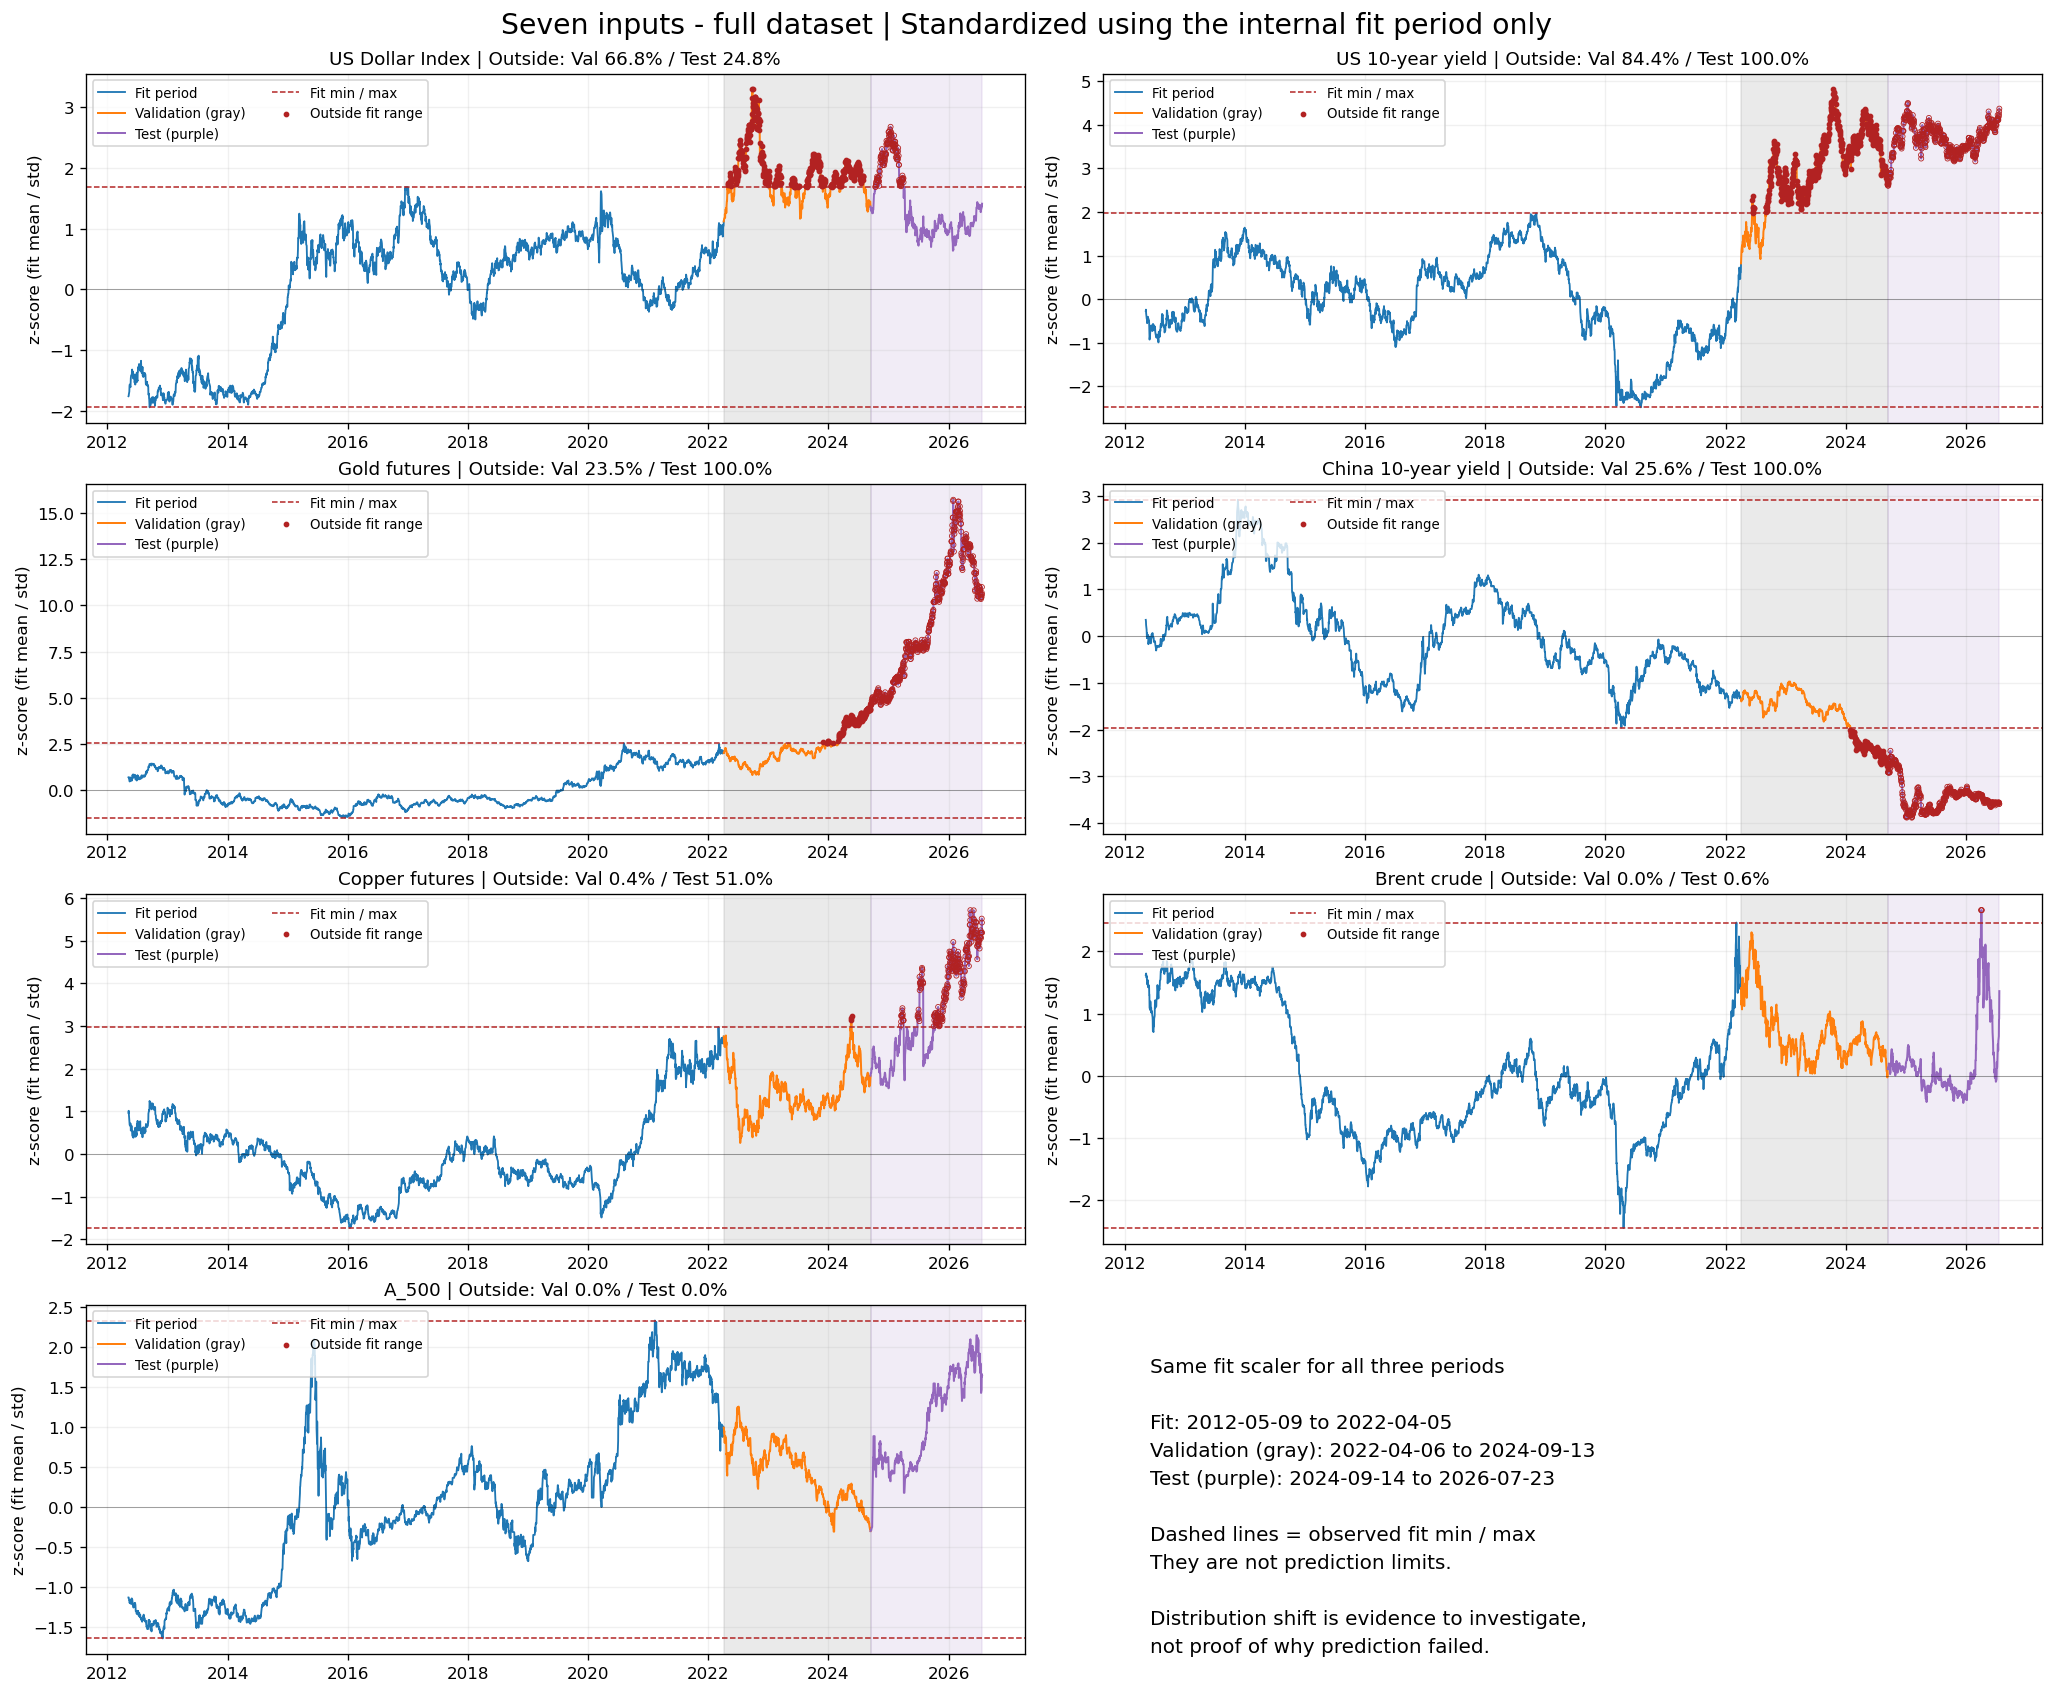

,拟合期最小 z,拟合期最大 z,拟合期均值 z,拟合期标准差 z,验证期最小 z,验证期最大 z,验证期均值 z,验证期标准差 z,验证期超范围比例 (%),测试期最小 z,测试期最大 z,测试期均值 z,测试期标准差 z,测试期超范围比例 (%)
因子,,,,,,,,,,,,,,
Dollar Index,-1.940,1.685,0.0,1.0,1.138,3.290,1.866,0.397,66.766,0.637,2.675,1.331,0.516,24.8
us_10y_rate,-2.479,1.968,0.0,1.0,0.922,4.813,2.938,0.879,84.431,2.606,4.503,3.684,0.327,100.0
Gold Futures Price,-1.529,2.521,-0.0,1.0,0.788,4.665,2.262,0.908,23.503,4.602,15.744,9.116,3.237,100.0
cn_10y_rate,-1.953,2.919,0.0,1.0,-2.845,-0.970,-1.663,0.487,25.599,-3.881,-2.451,-3.438,0.302,100.0
Copper Futures Price,-1.734,2.974,0.0,1.0,0.260,3.239,1.420,0.555,0.449,1.541,5.713,3.269,1.133,51.0
brent,-2.443,2.462,-0.0,1.0,-0.023,2.305,0.684,0.476,0.000,-0.434,2.661,0.218,0.604,0.6
A_500,-1.648,2.327,-0.0,1.0,-0.312,1.250,0.441,0.362,0.000,-0.293,2.143,1.060,0.579,0.0


In [ ]:
# 独立诊断变量：使用与 [5] 相同的拟合集，不改变模型或原标准化器。
feature_range_scaler = StandardScaler().fit(X_fit)
feature_range_z = pd.DataFrame(
    feature_range_scaler.transform(X), index=X.index, columns=X.columns)
feature_fit_z = feature_range_z.loc[X_fit.index]
feature_val_z = feature_range_z.loc[X_val.index]
feature_test_z = feature_range_z.loc[X_test.index]
feature_order = ['Dollar Index', 'us_10y_rate', 'Gold Futures Price',
                 'cn_10y_rate', 'Copper Futures Price', 'brent', 'A_500']
feature_titles = {'Dollar Index': 'US Dollar Index', 'us_10y_rate': 'US 10-year yield',
                  'Gold Futures Price': 'Gold futures', 'cn_10y_rate': 'China 10-year yield',
                  'Copper Futures Price': 'Copper futures', 'brent': 'Brent crude',
                  'A_500': 'A_500'}

feature_range_rows = []
feature_range_fig, feature_range_axes = plt.subplots(
    4, 2, figsize=(17, 14), sharex=True, constrained_layout=True)
for ax, feature in zip(feature_range_axes.flat, feature_order):
    fit_values, val_values = feature_fit_z[feature], feature_val_z[feature]
    test_values = feature_test_z[feature]
    low, high = fit_values.min(), fit_values.max()
    outside = (val_values < low) | (val_values > high)
    outside_test = (test_values < low) | (test_values > high)
    feature_range_rows.append({
        '因子': feature, '拟合期最小 z': low, '拟合期最大 z': high,
        '拟合期均值 z': fit_values.mean(), '拟合期标准差 z': fit_values.std(ddof=0),
        '验证期最小 z': val_values.min(), '验证期最大 z': val_values.max(),
        '验证期均值 z': val_values.mean(), '验证期标准差 z': val_values.std(ddof=0),
        '验证期超范围比例 (%)': outside.mean() * 100,
        '测试期最小 z': test_values.min(), '测试期最大 z': test_values.max(),
        '测试期均值 z': test_values.mean(), '测试期标准差 z': test_values.std(ddof=0),
        '测试期超范围比例 (%)': outside_test.mean() * 100})
    ax.axvspan(X_val.index.min(), X_val.index.max(), color='gray', alpha=0.16)
    ax.axvspan(X_test.index.min(), X_test.index.max(), color='tab:purple', alpha=0.12)
    ax.plot(fit_values.index, fit_values, color='tab:blue', linewidth=1.1, label='Fit period')
    # 带上边界前一个点，使时间线连续。
    val_line = feature_range_z[feature].iloc[len(X_fit) - 1:len(X_train)]
    ax.plot(val_line.index, val_line, color='tab:orange', linewidth=1.2, label='Validation (gray)')
    test_line = feature_range_z[feature].iloc[len(X_train) - 1:]
    ax.plot(test_line.index, test_line, color='tab:purple', linewidth=1.2, label='Test (purple)')
    ax.axhline(low, color='firebrick', linestyle='--', linewidth=0.9, label='Fit min / max')
    ax.axhline(high, color='firebrick', linestyle='--', linewidth=0.9)
    ax.scatter(val_values.index[outside], val_values[outside], color='firebrick',
               s=6, zorder=3, label='Outside fit range')
    ax.scatter(test_values.index[outside_test], test_values[outside_test],
               facecolors='none', edgecolors='firebrick', linewidths=0.5, s=9, zorder=3)
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.4)
    ax.set_title(f'{feature_titles[feature]} | Outside: Val {outside.mean():.1%} / Test {outside_test.mean():.1%}', fontsize=11)
    ax.set_ylabel('z-score (fit mean / std)')
    ax.grid(alpha=0.18)
    ax.tick_params(axis='x', labelbottom=True)
    ax.legend(loc='upper left', fontsize=8, ncol=2)
feature_range_axes.flat[-1].axis('off')
feature_range_axes.flat[-1].text(0.05, 0.85,
    'Same fit scaler for all three periods\n\n'
    'Fit: 2012-05-09 to 2022-04-05\n'
    'Validation (gray): 2022-04-06 to 2024-09-13\n'
    'Test (purple): 2024-09-14 to 2026-07-23\n\n'
    'Dashed lines = observed fit min / max\n'
    'They are not prediction limits.\n\n'
    'Distribution shift is evidence to investigate,\n'
    'not proof of why prediction failed.',
    transform=feature_range_axes.flat[-1].transAxes, va='top', fontsize=12, linespacing=1.6)
feature_range_fig.suptitle('Seven inputs - full dataset | Standardized using the internal fit period only', fontsize=17)
plt.show()
feature_range_summary = pd.DataFrame(feature_range_rows).set_index('因子')
display(feature_range_summary.round(3))


从训练集的效果来看,用MLP的方法,拟合的效果比Lasso效果好很多.随着训练次数增加,在拟合集的效果变得越来越好.

# 6 用完整的原训练集重新训练
现在轮数已经确定。重新拟合标准化器，使用全部原训练集；重新初始化模型，训练相同轮数。这样 MLP 和线性模型最终都能看到相同的训练记录。

验证期与完整训练期的分布可能不同，因此最佳轮数只是训练集内部选出的经验值，并不保证在未来仍然最优。

In [7]:
scaler_x_final = StandardScaler().fit(X_train)
scaler_y_final = StandardScaler().fit(Y_train.to_numpy().reshape(-1, 1))
X_train_tensor = to_tensor(scaler_x_final.transform(X_train))
X_test_tensor = to_tensor(scaler_x_final.transform(X_test))
Y_train_tensor = to_tensor(scaler_y_final.transform(Y_train.to_numpy().reshape(-1, 1)))

def fit_final_mlp(seed):
    model = build_mlp(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    for epoch in range(best_epoch):
        model.train()
        loss = loss_fn(model(X_train_tensor), Y_train_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return model

def predict_price(model, tensor):
    model.eval()
    with torch.no_grad():
        pred_scaled = model(tensor).cpu().numpy()
    return scaler_y_final.inverse_transform(pred_scaled).ravel()

mlp = fit_final_mlp(SEED)
Y_pred_mlp_train = predict_price(mlp, X_train_tensor)
Y_pred_mlp = predict_price(mlp, X_test_tensor)


# 7 在同一划分上重跑线性基准
Lasso 沿用原来 `utils/common.py` 的配置：标准化 Pipeline、五折 `TimeSeriesSplit`，以及 `10⁻⁵` 到 `10¹` 的 1000 个 alpha。每个内部折单独标准化，最终只在原训练集上拟合。

再加普通线性回归（OLS），观察差别是否主要来自 Lasso 惩罚。这里保留全部七列，不沿用后面把铜价和利率置零的实验。旧笔记有多次覆盖变量，不能直接拿旧输出中的约 0.79 当作本次七因子基准。

Lasso 用五折调 alpha，MLP 用训练末段选轮数；外部训练/测试样本完全相同，但内部调参方法不同，因此这次是入门模型比较，不是对非线性作用的严格因果分解。

In [8]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])
ts_split = TimeSeriesSplit(n_splits=5)
grid_lasso = GridSearchCV(
    estimator=pipe,
    param_grid={'lasso__alpha': np.logspace(-5, 1, 1000)},
    cv=ts_split,
    scoring='neg_root_mean_squared_error',
    refit=True
)
grid_lasso.fit(X_train, Y_train)
ols = Pipeline([('scaler', StandardScaler()), ('ols', LinearRegression())])
ols.fit(X_train, Y_train)
print('Lasso 最佳参数：', grid_lasso.best_params_)
print('Lasso 内部交叉验证 RMSE：', -grid_lasso.best_score_)


Lasso 最佳参数： {'lasso__alpha': np.float64(1e-05)}
Lasso 内部交叉验证 RMSE： 1.9296207017748177


# 8 保留 RMSE 和 R²，开始比较
RMSE 越低越好，单位与原股价一致；R² 越高越好，但不是“预测正确的百分比”，也可以小于零。

同时看训练和测试结果：训练很好、测试很差，说明学到的关系没有顺利迁移到测试时期。所有模型的评价都用同一组真实股价，并在原单位上计算。

,训练 RMSE,训练 R²,测试 RMSE,测试 R²
模型,,,,
OLS,0.7958,0.9617,3.6791,0.7900
Lasso,0.7958,0.9617,3.6791,0.7900
MLP 7-8-1 (seed=42),1.4000,0.8813,7.4255,0.1447


相对 Lasso 的测试 RMSE 降幅：-101.83%（负数表示变差）


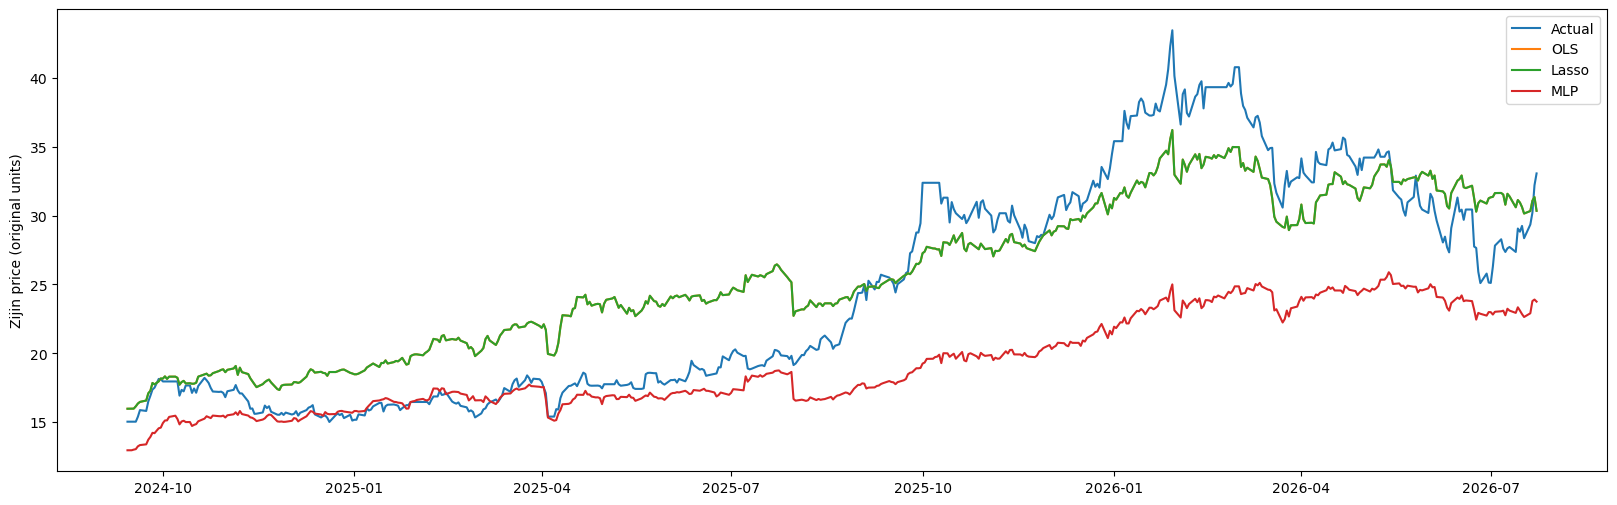

In [9]:
def evaluate(name, train_pred, test_pred):
    return {
        '模型': name,
        '训练 RMSE': np.sqrt(mean_squared_error(Y_train, train_pred)),
        '训练 R²': r2_score(Y_train, train_pred),
        '测试 RMSE': np.sqrt(mean_squared_error(Y_test, test_pred)),
        '测试 R²': r2_score(Y_test, test_pred)
    }

results = pd.DataFrame([
    evaluate('OLS', ols.predict(X_train), ols.predict(X_test)),
    evaluate('Lasso', grid_lasso.predict(X_train), grid_lasso.predict(X_test)),
    evaluate('MLP 7-8-1 (seed=42)', Y_pred_mlp_train, Y_pred_mlp)
]).set_index('模型')
display(results.round(4))
base_rmse = results.loc['Lasso', '测试 RMSE']
mlp_rmse = results.loc['MLP 7-8-1 (seed=42)', '测试 RMSE']
print(f'相对 Lasso 的测试 RMSE 降幅：{(1 - mlp_rmse / base_rmse) * 100:.2f}%（负数表示变差）')

predictions = pd.DataFrame({
    'Actual': Y_test,
    'OLS': ols.predict(X_test),
    'Lasso': grid_lasso.predict(X_test),
    'MLP': Y_pred_mlp
}, index=Y_test.index)
plt.figure(figsize=(20, 6))
for name in predictions:
    plt.plot(predictions.index, predictions[name], label=name)
plt.ylabel('Zijin price (original units)')
plt.legend()
plt.show()


# 9 小检查：换一个初始化，会不会碰巧得到不同结论？
神经网络从随机权重开始，单次结果可能碰巧好或差。预先固定再运行 `0、1、2、3` 四个种子，仍用上面已经确定的结构和轮数，不根据测试结果挑赢家，也不替换 seed=42 的主结果。

这只能检查初始化敏感性，不能替代不同历史时期的滚动验证。

In [10]:
seed_rows = [{'seed': SEED, '测试 RMSE': mlp_rmse,
              '测试 R²': r2_score(Y_test, Y_pred_mlp)}]
for seed in [0, 1, 2, 3]:
    trial = fit_final_mlp(seed)
    pred = predict_price(trial, X_test_tensor)
    seed_rows.append({'seed': seed,
                      '测试 RMSE': np.sqrt(mean_squared_error(Y_test, pred)),
                      '测试 R²': r2_score(Y_test, pred)})
seed_results = pd.DataFrame(seed_rows).set_index('seed')
display(seed_results.round(4))
display(seed_results.agg(['mean', 'std', 'min', 'max']).round(4))
print('五次中优于 Lasso 的次数：', int((seed_results['测试 RMSE'] < base_rmse).sum()))


,测试 RMSE,测试 R²
seed,,
42,7.4255,0.1447
0,7.8557,0.0427
1,5.1116,0.5947
2,6.5799,0.3284
3,5.8921,0.4615


,测试 RMSE,测试 R²
mean,6.5730,0.3144
std,1.1149,0.2253
min,5.1116,0.0427
max,7.8557,0.5947


五次中优于 Lasso 的次数： 0


# 10 怎么理解这次实验？
先看实际输出，再下结论，不预设神经网络一定更好：

- 如果测试 RMSE 降低、R² 提高，说明这个 MLP 在本次固定测试段上表现更好。
- 如果不同初始化差别很大，说明结果不稳定；不能只挑最好的一次。
- 如果没有提高，只能说这次小网络和训练设置没有带来改善，不能据此证明七个变量不存在非线性关系。

**保留原口径，也保留原数据的限制。** 旧数据处理代码使用过 `bfill()`，可能把未来观测填到过去；本次直接使用其保存数据，尚未审计每个填充值。因此这些数值是原数据口径下的比较，不是无泄漏的交易回测。

另外这里是 `X_t → Zijin_t`，没有把目标向后移动。境内外同一日期的收盘时间也不同，部分当日因子在 A 股收盘时还不可获得。因此不能把本次结果叫作“明日股价预测准确率”。要做未来预测，应另开实验统一处理可用时间、填充方式和目标滞后，再让所有模型使用同一套新数据。

下一步如果想加到 `7 → 16 → 1`，应在训练集内部先比较，不能反复看这 500 条测试数据调网络。本次先停在一层八个神经元，把训练过程和比较方法弄清楚。

PyTorch 学习参考：[官方训练与优化教程](https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html)。

自动生成的实验,在不同的训练集上进行训练,之前以小拟合集在验证集上的最好结果,以次数来作为最好的结果,本身没有道理.  
在验证集上,美元指数,美债等因素大幅飙升.模型没有见过这些自变量,可能在较小的范围内拟合的比较好,但是得到的参数在面对更大的自变量,误差会被放大.

# 11 本次实际运行结论

| 模型 | 训练 RMSE | 测试 RMSE | 测试 R² |
|---|---:|---:|---:|
| OLS | 0.7958 | 3.6791 | 0.7900 |
| 七因子 Lasso | 0.7958 | 3.6791 | 0.7900 |
| MLP 7 → 8 → 1，seed=42 | 1.4000 | 7.4255 | 0.1447 |

**这次小网络没有提高准确率。** 验证集选择第 29 轮，MLP 的测试 RMSE 比 Lasso 高约 101.83%。五个固定初始化的测试 RMSE 范围为 5.1116～7.8557，均未超过 Lasso；这不是只看某一次不好的结果。

MLP 连训练集上的误差也高于 OLS，因此不能直接说“网络把训练数据背下来，导致过拟合”。更准确的观察是：在当前结构、学习率和验证选轮规则下，拟合与跨时期迁移都不理想；训练期内部选出的较早停止点也可能不适合完整训练期。要区分这些原因，应在训练集内部研究学习曲线和多个时间窗口。

Lasso 的最佳 alpha 为搜索下界 0.00001，结果与 OLS 接近，说明本次选出的惩罚很弱。这个结论不能推广为所有时段都不需要正则化。

另一个数据检查发现：保存的数据包含周末日期，例如测试集首日为 **2024-09-14（周六）**。本次按原始索引保留最后 500 **条记录**，不能把它们称为 500 个真实交易日。后续需要回到源数据核对日历和填充值，再做可交易的预测实验。

以上是首次运行的记录；若以后改动参数，应重新运行比较表，并同步更新这一段结论。

# 12 再加大一点：两层隐藏层 16、32
这次在上一次实验后面继续，按给定顺序构建 **7 → 16 → 32 → 1**：第一层 16 个神经元，第二层 32 个。第二层可以比第一层宽，不要求逐层缩小。

第一层从七个因子学习 16 个组合，第二层再对这些组合做非线性变换，最后输出一个股价。参数从 73 个增加到 **705 个**：`7×16+16 + 16×32+32 + 32×1+1`。容量增加并不保证测试误差降低。

沿用相同的训练、验证、测试日期和标准化器，保持 Adam、学习率 0.01、最多 2000 轮、耐心值 150、主种子 42。**只改变网络结构，重新用内部验证集选择轮数**，不会直接沿用小网络的第 29 轮。

此前已经查看过测试结果，现在继续尝试结构，属于探索性比较；这 500 条记录已不是完全未见的最终检验集。

In [11]:
def build_mlp_two_layer(seed=SEED):
    torch.manual_seed(seed)
    return nn.Sequential(
        nn.Linear(7, 16),
        nn.ReLU(),
        nn.Linear(16, 32),
        nn.ReLU(),
        nn.Linear(32, 1)
    ).to(device)

model_two_layer = build_mlp_two_layer()
print(model_two_layer)
print('参数数量：', sum(p.numel() for p in model_two_layer.parameters()))


Sequential(
  (0): Linear(in_features=7, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)
参数数量： 705


## 12.1 先看新模型需要训练多久
训练过程与小模型一致，每次参数更新后计算验证 MSE。下面使用独立的变量名，保留前面的小模型与结果。

两层之间都放 ReLU，才能逐层学习非线性关系；输出层仍然保持线性。

两层模型验证集选择的轮数： 14


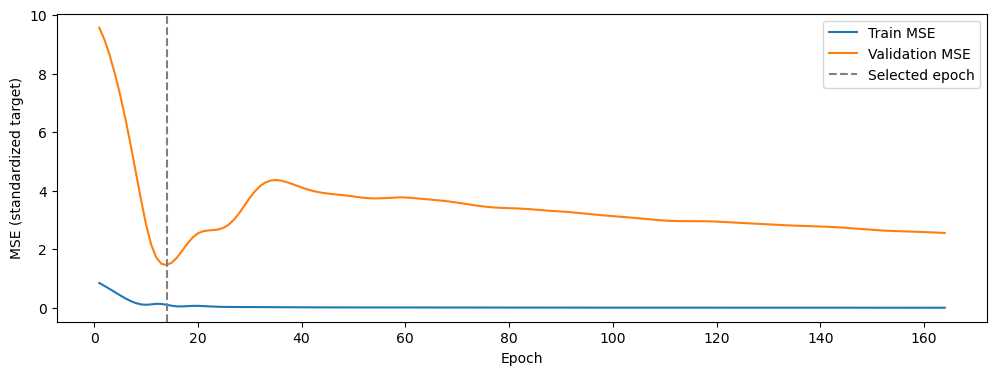

In [12]:
optimizer_two_layer = torch.optim.Adam(model_two_layer.parameters(), lr=LR)
history_two_layer = []
best_val_loss_two_layer = float('inf')
best_epoch_two_layer = 1
wait_two_layer = 0

for epoch in range(1, MAX_EPOCHS + 1):
    model_two_layer.train()
    prediction = model_two_layer(X_fit_tensor)
    loss = loss_fn(prediction, Y_fit_tensor)
    optimizer_two_layer.zero_grad()
    loss.backward()
    optimizer_two_layer.step()

    model_two_layer.eval()
    with torch.no_grad():
        train_loss = loss_fn(model_two_layer(X_fit_tensor), Y_fit_tensor).item()
        val_loss = loss_fn(model_two_layer(X_val_tensor), Y_val_tensor).item()
    assert np.isfinite(train_loss) and np.isfinite(val_loss)
    history_two_layer.append([epoch, train_loss, val_loss])
    if val_loss < best_val_loss_two_layer - 1e-6:
        best_val_loss_two_layer = val_loss
        best_epoch_two_layer = epoch
        wait_two_layer = 0
    else:
        wait_two_layer += 1
    if epoch % 200 == 0:
        print(f'Epoch {epoch}：训练 MSE={train_loss:.4f}，验证 MSE={val_loss:.4f}')
    if wait_two_layer >= PATIENCE:
        break

history_two_layer = pd.DataFrame(history_two_layer,
                                 columns=['epoch', 'train_mse', 'val_mse'])
print('两层模型验证集选择的轮数：', best_epoch_two_layer)
plt.figure(figsize=(12, 4))
plt.plot(history_two_layer.epoch, history_two_layer.train_mse, label='Train MSE')
plt.plot(history_two_layer.epoch, history_two_layer.val_mse, label='Validation MSE')
plt.axvline(best_epoch_two_layer, color='gray', linestyle='--', label='Selected epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE (standardized target)')
plt.legend()
plt.show()


## 12.2 重新初始化，在全部原训练集训练
用刚刚选出的轮数训练新的两层模型，仍然使用前面只在完整训练集上拟合的标准化器。输出还原成原股价单位，继续比较 RMSE 和 R²。

,训练 RMSE,训练 R²,测试 RMSE,测试 R²
模型,,,,
OLS,0.7958,0.9617,3.6791,0.7900
Lasso,0.7958,0.9617,3.6791,0.7900
MLP 7-8-1 (seed=42),1.4000,0.8813,7.4255,0.1447
MLP 7-16-32-1 (seed=42),1.5345,0.8574,5.5890,0.5154


相对小模型的测试 RMSE 降幅：24.73%
相对 Lasso 的测试 RMSE 降幅：-51.91%


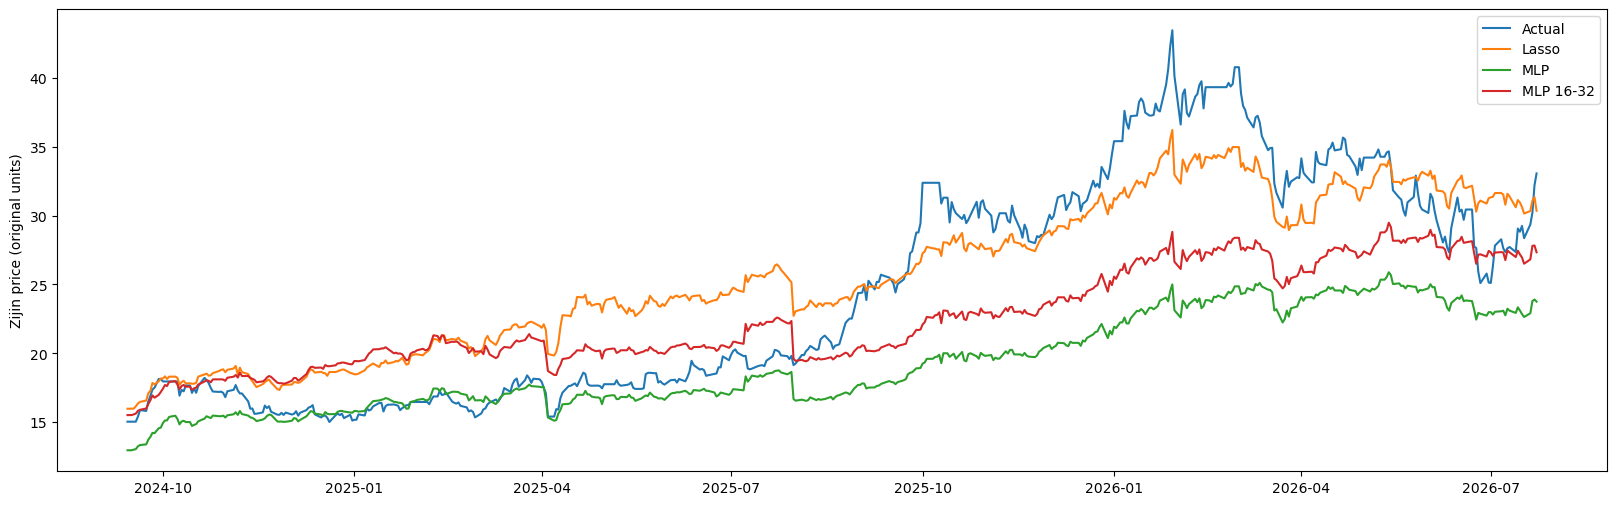

In [13]:
def fit_final_two_layer(seed):
    model = build_mlp_two_layer(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    for epoch in range(best_epoch_two_layer):
        model.train()
        loss = loss_fn(model(X_train_tensor), Y_train_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return model

mlp_two_layer = fit_final_two_layer(SEED)
Y_pred_two_layer_train = predict_price(mlp_two_layer, X_train_tensor)
Y_pred_two_layer = predict_price(mlp_two_layer, X_test_tensor)
results_two_layer = pd.concat([
    results,
    pd.DataFrame([evaluate('MLP 7-16-32-1 (seed=42)',
                           Y_pred_two_layer_train, Y_pred_two_layer)]).set_index('模型')
])
display(results_two_layer.round(4))
two_rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_two_layer))
print(f'相对小模型的测试 RMSE 降幅：{(1 - two_rmse / mlp_rmse) * 100:.2f}%')
print(f'相对 Lasso 的测试 RMSE 降幅：{(1 - two_rmse / base_rmse) * 100:.2f}%')

predictions_two_layer = predictions.copy()
predictions_two_layer['MLP 16-32'] = Y_pred_two_layer
plt.figure(figsize=(20, 6))
for name in ['Actual', 'Lasso', 'MLP', 'MLP 16-32']:
    plt.plot(predictions_two_layer.index, predictions_two_layer[name], label=name)
plt.ylabel('Zijin price (original units)')
plt.legend()
plt.show()


## 12.3 与之前一样，检查初始化敏感性
继续使用同样的五个种子。新增四次训练仍然用主种子验证集选出的轮数，不根据测试表现改轮数或选择最好的种子。这一检查反映固定训练方案对初始化是否敏感。

In [14]:
seed_rows_two_layer = [{'seed': SEED, '测试 RMSE': two_rmse,
                        '测试 R²': r2_score(Y_test, Y_pred_two_layer)}]
for seed in [0, 1, 2, 3]:
    trial_two_layer = fit_final_two_layer(seed)
    pred_two_layer = predict_price(trial_two_layer, X_test_tensor)
    seed_rows_two_layer.append({
        'seed': seed,
        '测试 RMSE': np.sqrt(mean_squared_error(Y_test, pred_two_layer)),
        '测试 R²': r2_score(Y_test, pred_two_layer)
    })
seed_results_two_layer = pd.DataFrame(seed_rows_two_layer).set_index('seed')
display(seed_results_two_layer.round(4))
display(seed_results_two_layer.agg(['mean', 'std', 'min', 'max']).round(4))
print('五次中优于 Lasso 的次数：', int((seed_results_two_layer['测试 RMSE'] < base_rmse).sum()))


,测试 RMSE,测试 R²
seed,,
42,5.5890,0.5154
0,4.0922,0.7402
1,4.6519,0.6643
2,5.1058,0.5956
3,5.0790,0.5998


,测试 RMSE,测试 R²
mean,4.9036,0.6231
std,0.5620,0.0841
min,4.0922,0.5154
max,5.5890,0.7402


五次中优于 Lasso 的次数： 0


## 12.4 这次扩大模型后的结果
下面的总结随代码运行自动更新。先区分“比小模型好”和“比线性基准好”，这是两个不同的问题。

训练误差与测试误差之间的变化可以帮助定位问题，但单次实验不能单独证明过拟合或真实非线性规律。前面关于填充方式、交易日历和同日解释的限制仍然适用。

In [15]:
two_r2 = r2_score(Y_test, Y_pred_two_layer)
print(f'两层模型：705 个参数，验证集选择 {best_epoch_two_layer} 轮。')
print(f'测试 RMSE={two_rmse:.4f}，测试 R²={two_r2:.4f}。')
print('相比小模型：' + ('误差降低。' if two_rmse < mlp_rmse else '误差没有降低。'))
print('相比 Lasso：' + ('本次测试段误差降低。' if two_rmse < base_rmse else '本次测试段误差没有降低。'))
print(f"五个初始化的平均测试 RMSE={seed_results_two_layer['测试 RMSE'].mean():.4f}，"
      f"范围 {seed_results_two_layer['测试 RMSE'].min():.4f}～"
      f"{seed_results_two_layer['测试 RMSE'].max():.4f}。")


两层模型：705 个参数，验证集选择 14 轮。
测试 RMSE=5.5890，测试 R²=0.5154。
相比小模型：误差降低。
相比 Lasso：本次测试段误差没有降低。
五个初始化的平均测试 RMSE=4.9036，范围 4.0922～5.5890。


# 13 分开试：加深一次，加宽一次
前面已经尝试了 `7 → 16 → 32 → 1`，现在沿两个方向各做一组实验：

| 方向 | 隐藏层 | 完整结构 | 参数数量 |
|---|---|---|---:|
| 原两层模型 | 16、32 | 7 → 16 → 32 → 1 | 705 |
| 加深 | 16、32、16 | 7 → 16 → 32 → 16 → 1 | 1217 |
| 加宽 | 32、64 | 7 → 32 → 64 → 1 | 2433 |

**加深**是在原隐藏层后增加一层，让模型多做一次非线性组合。**加宽**保持两个隐藏层，但把每层神经元数量翻倍，让每一层容纳更多组合。

这两组的参数总量不同，因此可以比较实际效果，但不是参数量完全相同的深度与宽度对照。

依旧使用原来的七个因子、3337 条训练记录、最后 500 条测试记录。主种子 42，Adam 学习率 0.01，最多 2000 轮，连续 150 轮验证误差无改善则停止。每种结构自己选择训练轮数，再从头在全部训练集上训练。

本次预先确定这两种结构，不在看到测试结果后临时改网络。由于此前已多次看过测试集，这仍是探索实验，不能当作新的独立验证。

## 13.1 先看两个模型长什么样
仍然明确写出每一层。注意每个隐藏层后面都有 ReLU，输出层没有激活函数。

输入的七个因子没有变；变化的是模型内部如何组合它们。

In [16]:
def build_deeper_mlp(seed=SEED):
    torch.manual_seed(seed)
    return nn.Sequential(
        nn.Linear(7, 16), nn.ReLU(),
        nn.Linear(16, 32), nn.ReLU(),
        nn.Linear(32, 16), nn.ReLU(),
        nn.Linear(16, 1)
    ).to(device)

def build_wider_mlp(seed=SEED):
    torch.manual_seed(seed)
    return nn.Sequential(
        nn.Linear(7, 32), nn.ReLU(),
        nn.Linear(32, 64), nn.ReLU(),
        nn.Linear(64, 1)
    ).to(device)

for name, builder in [('加深', build_deeper_mlp), ('加宽', build_wider_mlp)]:
    candidate = builder()
    print(name, candidate)
    print('参数数量：', sum(p.numel() for p in candidate.parameters()))


加深 Sequential(
  (0): Linear(in_features=7, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=1, bias=True)
)
参数数量： 1217
加宽 Sequential(
  (0): Linear(in_features=7, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=1, bias=True)
)
参数数量： 2433


## 13.2 把相同的训练步骤整理成函数
前面已经逐行学过训练过程。这次将相同逻辑放进一个函数，保证加深与加宽使用相同规则，也避免复制后漏改某一处。

函数接收“创建模型的方法”，完成三件事：
1. 在内部拟合集训练，在内部验证集挑轮数；这里只接触训练期数据。
2. 重新初始化，用挑出的轮数在完整原训练集上训练。
3. 返回训练好的模型、轮数和学习曲线，随后统一评估。

这里的 Tensor 和标准化器全部复用前面的对象，因此不会重新切分日期，也不会用测试数据拟合标准化器。

In [17]:
def fit_with_selected_epochs(builder):
    candidate = builder(SEED)
    optimizer = torch.optim.Adam(candidate.parameters(), lr=LR)
    best_val = float('inf')
    selected_epoch = 1
    waiting = 0
    curve = []

    for epoch in range(1, MAX_EPOCHS + 1):
        candidate.train()
        loss = loss_fn(candidate(X_fit_tensor), Y_fit_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        candidate.eval()
        with torch.no_grad():
            train_loss = loss_fn(candidate(X_fit_tensor), Y_fit_tensor).item()
            val_loss = loss_fn(candidate(X_val_tensor), Y_val_tensor).item()
        assert np.isfinite(train_loss) and np.isfinite(val_loss)
        curve.append([epoch, train_loss, val_loss])
        if val_loss < best_val - 1e-6:
            best_val = val_loss
            selected_epoch = epoch
            waiting = 0
        else:
            waiting += 1
        if waiting >= PATIENCE:
            break

    final_model = refit_architecture(builder, selected_epoch, SEED)
    return {
        'model': final_model,
        'epochs': selected_epoch,
        'validation_rmse': np.sqrt(best_val) * scaler_y.scale_[0],
        'curve': pd.DataFrame(curve, columns=['epoch', 'train_mse', 'val_mse'])
    }

def refit_architecture(builder, epochs, seed):
    candidate = builder(seed)
    optimizer = torch.optim.Adam(candidate.parameters(), lr=LR)
    for epoch in range(epochs):
        candidate.train()
        loss = loss_fn(candidate(X_train_tensor), Y_train_tensor)
        assert torch.isfinite(loss).item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return candidate


## 13.3 分别训练，看验证集选了多少轮
更大网络可能更快降低训练误差，所以不一定需要更多轮。选中的轮数不同，是相同验证规则产生的结果；并不意味着给其中一个模型看了更多训练日期。

,方向,参数量,选择轮数,内部验证 RMSE
0,加深 16-32-16,1217,13,2.6653
1,加宽 32-64,2433,11,3.2142


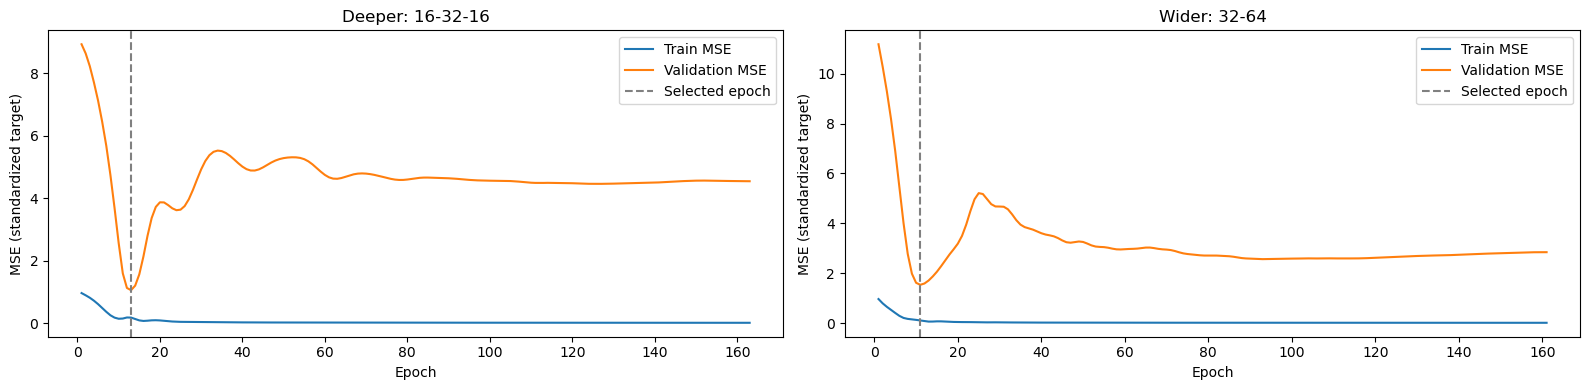

In [18]:
deeper_run = fit_with_selected_epochs(build_deeper_mlp)
wider_run = fit_with_selected_epochs(build_wider_mlp)

selection_table = pd.DataFrame([
    {'方向': name, '参数量': sum(p.numel() for p in run['model'].parameters()),
     '选择轮数': run['epochs'], '内部验证 RMSE': run['validation_rmse']}
    for name, run in [('加深 16-32-16', deeper_run), ('加宽 32-64', wider_run)]
])
display(selection_table.round(4))
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, name, run in zip(axes, ['Deeper: 16-32-16', 'Wider: 32-64'],
                         [deeper_run, wider_run]):
    curve = run['curve']
    ax.plot(curve.epoch, curve.train_mse, label='Train MSE')
    ax.plot(curve.epoch, curve.val_mse, label='Validation MSE')
    ax.axvline(run['epochs'], color='gray', linestyle='--', label='Selected epoch')
    ax.set(title=name, xlabel='Epoch', ylabel='MSE (standardized target)')
    ax.legend()
plt.tight_layout()
plt.show()


## 13.4 同一个测试集，放在一张表里比较
依旧报告原股价单位下的 RMSE 和 R²，同时显示训练指标。先比较原两层模型，再看是否超过 Lasso；不能把“比上一版好”误当成“已经优于线性模型”。

,训练 RMSE,训练 R²,测试 RMSE,测试 R²
模型,,,,
OLS,0.7958,0.9617,3.6791,0.7900
Lasso,0.7958,0.9617,3.6791,0.7900
MLP 7-8-1 (seed=42),1.4000,0.8813,7.4255,0.1447
MLP 7-16-32-1 (seed=42),1.5345,0.8574,5.5890,0.5154
MLP deeper 16-32-16 (seed=42),1.7221,0.8205,7.1706,0.2024
MLP wider 32-64 (seed=42),1.4788,0.8676,4.3822,0.7021


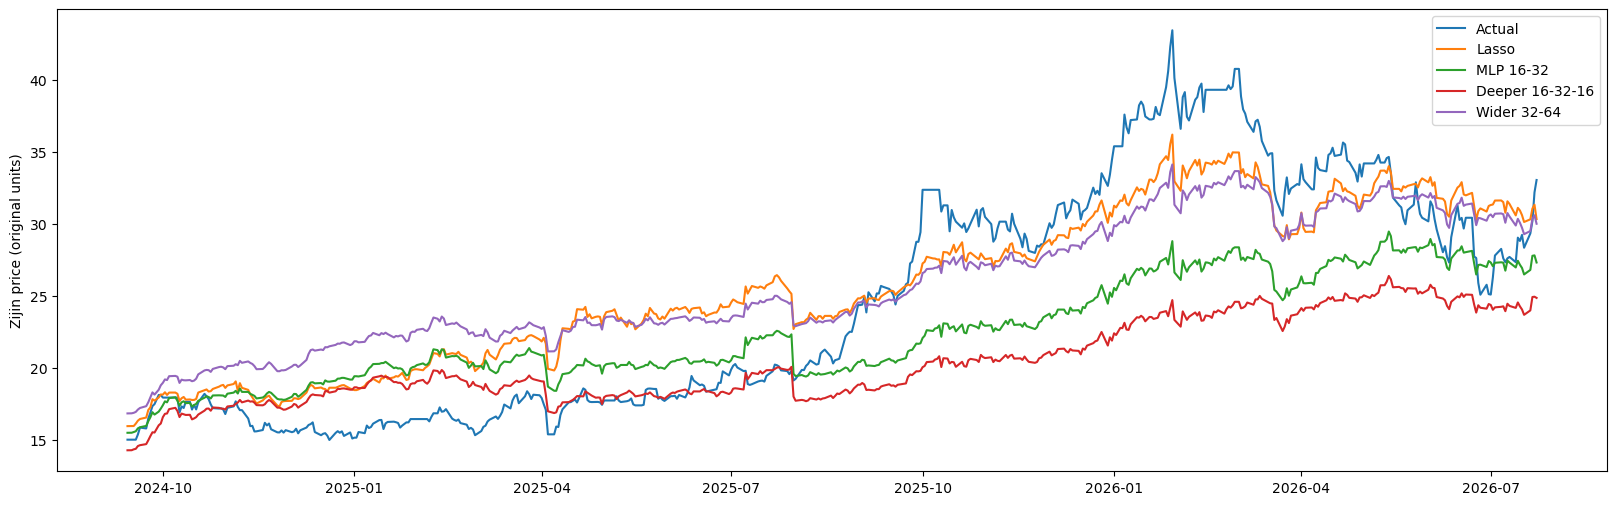

In [19]:
depth_width_rows = []
predictions_depth_width = predictions_two_layer.copy()
for name, key, run in [
    ('MLP deeper 16-32-16 (seed=42)', 'Deeper 16-32-16', deeper_run),
    ('MLP wider 32-64 (seed=42)', 'Wider 32-64', wider_run)
]:
    train_pred = predict_price(run['model'], X_train_tensor)
    test_pred = predict_price(run['model'], X_test_tensor)
    depth_width_rows.append(evaluate(name, train_pred, test_pred))
    predictions_depth_width[key] = test_pred

results_depth_width = pd.concat([
    results_two_layer,
    pd.DataFrame(depth_width_rows).set_index('模型')
])
display(results_depth_width.round(4))

plt.figure(figsize=(20, 6))
for name in ['Actual', 'Lasso', 'MLP 16-32', 'Deeper 16-32-16', 'Wider 32-64']:
    plt.plot(predictions_depth_width.index, predictions_depth_width[name], label=name)
plt.ylabel('Zijin price (original units)')
plt.legend()
plt.show()


## 13.5 仍然检查五个初始化，不从中挑最好的一次
这与前两次的检查一致：种子固定为 42、0、1、2、3，每种结构使用自己的主种子验证选轮结果。下面比较相同初始化编号下的指标，再汇总平均值与波动。

平均值是在汇总五次独立训练的评分，**不是把五个预测取平均后的集成模型评分**。

In [20]:
depth_width_seed_rows = []
for label, key, builder, run in [
    ('Deeper 16-32-16', 'Deeper 16-32-16', build_deeper_mlp, deeper_run),
    ('Wider 32-64', 'Wider 32-64', build_wider_mlp, wider_run)
]:
    for seed in [42, 0, 1, 2, 3]:
        if seed == SEED:
            pred = predictions_depth_width[key].to_numpy()
        else:
            trial = refit_architecture(builder, run['epochs'], seed)
            pred = predict_price(trial, X_test_tensor)
        depth_width_seed_rows.append({
            '模型': label, 'seed': seed,
            '测试 RMSE': np.sqrt(mean_squared_error(Y_test, pred)),
            '测试 R²': r2_score(Y_test, pred)
        })

depth_width_seeds = pd.DataFrame(depth_width_seed_rows)
all_seed_results = pd.concat([
    seed_results.reset_index().assign(模型='Small 8'),
    seed_results_two_layer.reset_index().assign(模型='Two-layer 16-32'),
    depth_width_seeds
], ignore_index=True)
display(depth_width_seeds.set_index(['模型', 'seed']).round(4))
display(all_seed_results.groupby('模型', sort=False)[['测试 RMSE', '测试 R²']]
        .agg(['mean', 'std', 'min', 'max']).round(4))


测试 RMSE   测试 R²
模型              seed                 
Deeper 16-32-16 42     7.1706  0.2024
                0      4.0461  0.7460
                1      4.7880  0.6444
                2      4.2309  0.7223
                3      6.1425  0.4147
Wider 32-64     42     4.3822  0.7021
                0      5.2407  0.5740
                1      4.3851  0.7017
                2      6.5907  0.3262
                3      7.4479  0.1395

测试 RMSE                           测试 R²                  \
                   mean     std     min     max    mean     std     min   
模型                                                                        
Small 8          6.5730  1.1149  5.1116  7.8557  0.3144  0.2253  0.0427   
Two-layer 16-32  4.9036  0.5620  4.0922  5.5890  0.6231  0.0841  0.5154   
Deeper 16-32-16  5.2756  1.3401  4.0461  7.1706  0.5460  0.2324  0.2024   
Wider 32-64      5.6093  1.3678  4.3822  7.4479  0.4887  0.2483  0.1395   

                         
                    max  
模型                       
Small 8          0.5947  
Two-layer 16-32  0.7402  
Deeper 16-32-16  0.7460  
Wider 32-64      0.7021

## 13.6 根据输出下结论
如果只看训练误差，网络越大越容易给人“模型更好”的错觉。这里以同一测试段的 RMSE 和 R²为依据，并结合初始化波动理解结果。

即使加深或加宽成功超过线性基准，也只能说明本次固定测试段的表现改善。原数据的向后填充、周末记录、同日解释问题，以及反复查看测试集的问题都仍然存在。

In [21]:
for label, row in zip(['加深', '加宽'], depth_width_rows):
    rmse = row['测试 RMSE']
    print(f"{label}：测试 RMSE={rmse:.4f}，R²={row['测试 R²']:.4f}。")
    print(f'相对原两层模型 RMSE 降幅：{(1 - rmse / two_rmse) * 100:.2f}%')
    print(f'相对 Lasso RMSE 降幅：{(1 - rmse / base_rmse) * 100:.2f}%（负数表示变差）')
for name, group in depth_width_seeds.groupby('模型', sort=False):
    wins = int((group['测试 RMSE'] < base_rmse).sum())
    print(f'{name}：五次初始化中优于 Lasso 的次数为 {wins}/5。')


加深：测试 RMSE=7.1706，R²=0.2024。
相对原两层模型 RMSE 降幅：-28.30%
相对 Lasso RMSE 降幅：-94.90%（负数表示变差）
加宽：测试 RMSE=4.3822，R²=0.7021。
相对原两层模型 RMSE 降幅：21.59%
相对 Lasso RMSE 降幅：-19.11%（负数表示变差）
Deeper 16-32-16：五次初始化中优于 Lasso 的次数为 0/5。
Wider 32-64：五次初始化中优于 Lasso 的次数为 0/5。


## 13.7 本次观察：单次加宽有改善，但稳定性没有提高

主种子 42 下，加深模型选择 13 轮，测试 RMSE 为 7.1706、R² 为 0.2024，比原两层模型更差。加宽模型选择 11 轮，测试 RMSE 为 4.3822、R² 为 0.7021，比原两层模型的 RMSE 降低约 21.59%，但仍没有超过 Lasso。

如果看五次初始化的平均测试 RMSE：原两层模型为 **4.9036**，加深为 **5.2756**，加宽为 **5.6093**。因此不能仅凭 seed=42 的改善就说“加宽一定有效”；两种扩容方案在初始化之间的波动都更大。本次两组共十次训练均未超过 Lasso。

此外，新模型训练 RMSE 仍高于 OLS，不能直接归结为典型的“训练近乎完美、测试很差”的过拟合。当前固定学习率、较早的验证最优轮数以及跨时期分布差异，都可能影响结果。下一步更值得在训练集内部检查优化过程和验证窗口，而不是继续盲目增加参数。

这一段记录本次运行值；若以后改动参数，应同步更新。

# 14 参考 AlexNet，试一次更大的网络
AlexNet 原本是图像分类网络。Torchvision 实现包括五个卷积层和三个全连接层，并使用 ReLU、池化和 Dropout。参考：[Torchvision 官方 AlexNet 源码](https://docs.pytorch.org/vision/main/_modules/torchvision/models/alexnet.html)。

七个宏观因子是一行表格，不是图像；因子排列也不代表像素邻近关系。因此这次**借用五层特征提取、三层输出网络的层级，以及 ReLU、Dropout 的设计**，将卷积特征提取改为全连接变换，不使用池化，不加载 ImageNet 权重。宽度做了缩减，输出改为一个连续股价。

这是 **AlexNet-inspired Dense（参考 AlexNet 的全连接改编版）**，不是原版 AlexNet，也不能据此评价原版 AlexNet 对金融数据的能力。

结构为：

`7 → 32 → 96 → 192 → 128 → 128 → 128 → 128 → 1`

前五层逐步组合七个因子，后三个线性层负责回归输出。各隐藏层使用 ReLU；输出头的两个隐藏变换前使用 Dropout(0.5)，参考官方分类头的安排。最后一层没有 ReLU，保持股价回归输出。

这次主种子仍为 42，使用相同的数据、内部验证段、最终测试段和标准化器。预先把学习率设为 0.001，最多 2000 轮，耐心值 150。与旧模型相比，结构、Dropout 和学习率同时变化，因此是一个新配置测试，不是单独检验模型大小。只跑一次主种子，不根据测试结果继续调参。

In [22]:
ALEX_LR = 0.001
ALEX_DROPOUT = 0.5
ALEX_MAX_EPOCHS = 2000
ALEX_PATIENCE = 150

class AlexInspiredDense(nn.Module):
    def __init__(self):
        super().__init__()
        # 五个全连接特征变换；不把七个因子伪装成图像。
        self.features = nn.Sequential(
            nn.Linear(7, 32), nn.ReLU(),
            nn.Linear(32, 96), nn.ReLU(),
            nn.Linear(96, 192), nn.ReLU(),
            nn.Linear(192, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU()
        )
        # 参考 AlexNet 的三层全连接输出头，宽度缩减为 128。
        self.regressor = nn.Sequential(
            nn.Dropout(ALEX_DROPOUT),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Dropout(ALEX_DROPOUT),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.regressor(self.features(x))

def build_alex_inspired(seed=SEED):
    torch.manual_seed(seed)
    return AlexInspiredDense().to(device)

alex_candidate = build_alex_inspired()
alex_params = sum(p.numel() for p in alex_candidate.parameters())
print(alex_candidate)
print('参数数量：', alex_params)
# 每个 Linear 都有可训练截距，输出层也有。
assert all(layer.bias is not None for layer in alex_candidate.modules()
           if isinstance(layer, nn.Linear))
print('所有线性层均包含截距 bias。')


AlexInspiredDense(
  (features): Sequential(
    (0): Linear(in_features=7, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=96, bias=True)
    (3): ReLU()
    (4): Linear(in_features=96, out_features=192, bias=True)
    (5): ReLU()
    (6): Linear(in_features=192, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): ReLU()
  )
  (regressor): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)
参数数量： 96417
所有线性层均包含截距 bias。


## 14.1 这次要特别理解 train() 和 eval()
Dropout 在训练时随机屏蔽一部分中间输出，让模型不能总是依赖同一组神经元；它不会删除原来的七列数据，也不会永久删除参数。

`model.train()` 开启 Dropout，`model.eval()` 关闭 Dropout。因此训练更新时启用它，计算训练/验证曲线和最终预测时关闭它。下面曲线都在 eval 模式下计算，便于相互比较。Dropout 是一种正则化方法，不能保证模型一定不再过拟合。

仍然只在内部拟合集拟合参数，根据内部验证误差选轮数，不用测试误差来早停。

Epoch 100：训练 MSE=0.0194，验证 MSE=5.3285


验证集选择轮数： 29
内部验证 RMSE（原股价单位）： 4.420912499437133


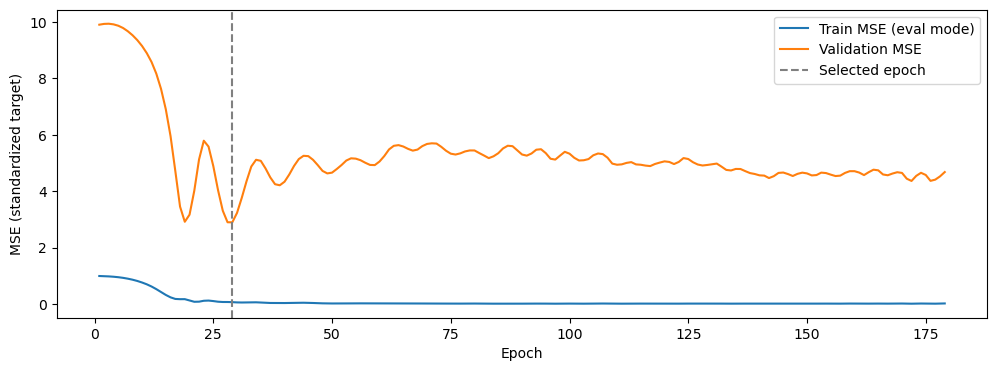

In [23]:
alex_optimizer = torch.optim.Adam(alex_candidate.parameters(), lr=ALEX_LR)
alex_curve_rows = []
alex_best_val = float('inf')
alex_best_epoch = 1
alex_wait = 0

for epoch in range(1, ALEX_MAX_EPOCHS + 1):
    alex_candidate.train()
    loss = loss_fn(alex_candidate(X_fit_tensor), Y_fit_tensor)
    alex_optimizer.zero_grad()
    loss.backward()
    alex_optimizer.step()

    alex_candidate.eval()
    with torch.no_grad():
        train_loss = loss_fn(alex_candidate(X_fit_tensor), Y_fit_tensor).item()
        val_loss = loss_fn(alex_candidate(X_val_tensor), Y_val_tensor).item()
    assert np.isfinite(train_loss) and np.isfinite(val_loss)
    alex_curve_rows.append([epoch, train_loss, val_loss])
    if val_loss < alex_best_val - 1e-6:
        alex_best_val = val_loss
        alex_best_epoch = epoch
        alex_wait = 0
    else:
        alex_wait += 1
    if epoch % 100 == 0:
        print(f'Epoch {epoch}：训练 MSE={train_loss:.4f}，验证 MSE={val_loss:.4f}', flush=True)
    if alex_wait >= ALEX_PATIENCE:
        break

alex_history = pd.DataFrame(alex_curve_rows, columns=['epoch', 'train_mse', 'val_mse'])
print('验证集选择轮数：', alex_best_epoch)
print('内部验证 RMSE（原股价单位）：', np.sqrt(alex_best_val) * scaler_y.scale_[0])
plt.figure(figsize=(12, 4))
plt.plot(alex_history.epoch, alex_history.train_mse, label='Train MSE (eval mode)')
plt.plot(alex_history.epoch, alex_history.val_mse, label='Validation MSE')
plt.axvline(alex_best_epoch, color='gray', linestyle='--', label='Selected epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE (standardized target)')
plt.legend()
plt.show()


## 14.2 用选定轮数，在全部原训练集重新训练
重新初始化，使用完整训练集训练相同轮数，不继续使用内部拟合模型的参数。这样最后用于预测的模型仍然看到了与 Lasso 相同的训练记录。

标准化后的预测由前面的 `predict_price` 还原到股价单位；该函数内部调用 eval()，确保测试时关闭 Dropout。

,训练 RMSE,训练 R²,测试 RMSE,测试 R²
模型,,,,
OLS,0.7958,0.9617,3.6791,0.7900
Lasso,0.7958,0.9617,3.6791,0.7900
MLP 7-8-1 (seed=42),1.4000,0.8813,7.4255,0.1447
MLP 7-16-32-1 (seed=42),1.5345,0.8574,5.5890,0.5154
MLP deeper 16-32-16 (seed=42),1.7221,0.8205,7.1706,0.2024
MLP wider 32-64 (seed=42),1.4788,0.8676,4.3822,0.7021
AlexNet-inspired Dense (seed=42),1.3025,0.8973,8.3958,-0.0935


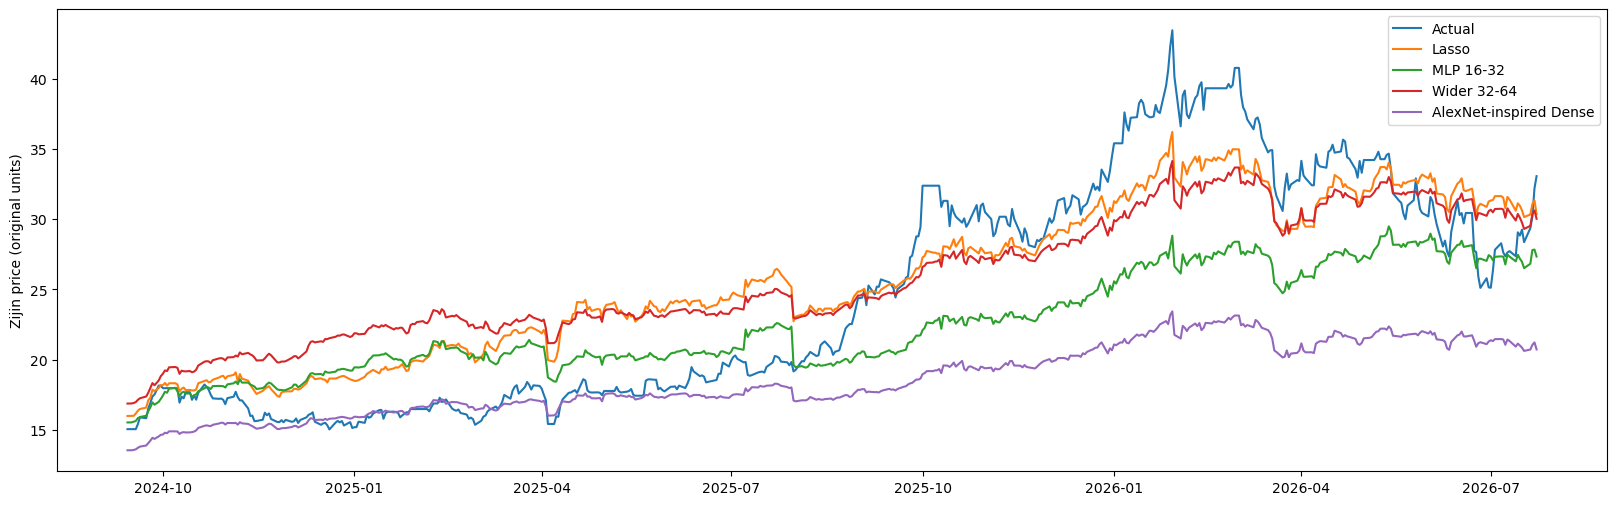

In [24]:
alex_model = build_alex_inspired()
alex_final_optimizer = torch.optim.Adam(alex_model.parameters(), lr=ALEX_LR)
for epoch in range(1, alex_best_epoch + 1):
    alex_model.train()
    loss = loss_fn(alex_model(X_train_tensor), Y_train_tensor)
    assert torch.isfinite(loss).item()
    alex_final_optimizer.zero_grad()
    loss.backward()
    alex_final_optimizer.step()

Y_pred_alex_train = predict_price(alex_model, X_train_tensor)
Y_pred_alex = predict_price(alex_model, X_test_tensor)
alex_row = evaluate('AlexNet-inspired Dense (seed=42)', Y_pred_alex_train, Y_pred_alex)
results_alex = pd.concat([
    results_depth_width,
    pd.DataFrame([alex_row]).set_index('模型')
])
display(results_alex.round(4))

predictions_alex = predictions_depth_width.copy()
predictions_alex['AlexNet-inspired Dense'] = Y_pred_alex
plt.figure(figsize=(20, 6))
for name in ['Actual', 'Lasso', 'MLP 16-32', 'Wider 32-64', 'AlexNet-inspired Dense']:
    plt.plot(predictions_alex.index, predictions_alex[name], label=name)
plt.ylabel('Zijin price (original units)')
plt.legend()
plt.show()


## 14.3 回到刚才“是不是缺截距”的问题
这次所有线性层仍然带 bias，且所有 bias 都交给优化器更新。有截距不代表不会产生系统性偏差。

可以计算 `真实值 - 预测值` 的平均值：正数表示平均低估，负数表示平均高估。对测试段计算残差仅用于诊断，下面不会据此平移预测或重新打分。

同时看残差随时间的变化：如果偏差大小随时期变化，单加一个常数无法修正全部问题。

训练集平均残差： -0.5620329886022928
测试集平均残差： 6.099075121383667


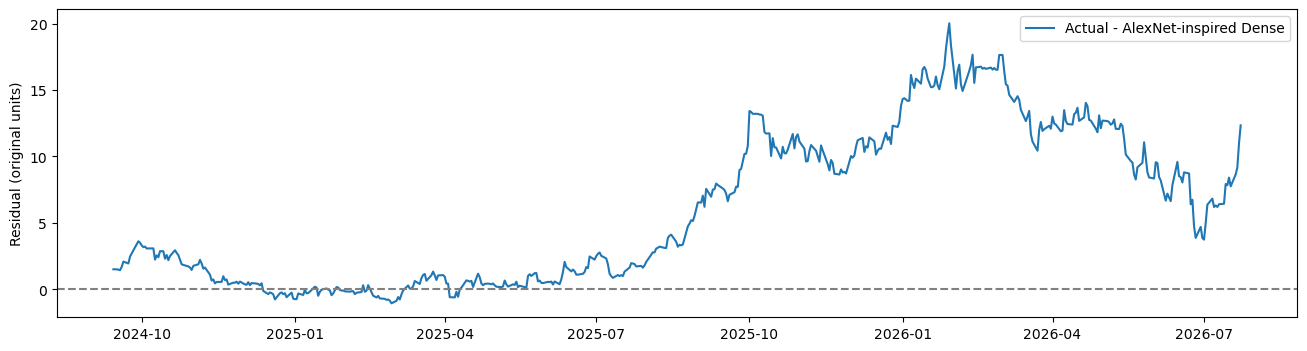

In [25]:
alex_residual_train = Y_train.to_numpy() - Y_pred_alex_train
alex_residual_test = Y_test.to_numpy() - Y_pred_alex
print('训练集平均残差：', alex_residual_train.mean())
print('测试集平均残差：', alex_residual_test.mean())
plt.figure(figsize=(16, 4))
plt.plot(Y_test.index, alex_residual_test, label='Actual - AlexNet-inspired Dense')
plt.axhline(0, color='gray', linestyle='--')
plt.ylabel('Residual (original units)')
plt.legend()
plt.show()


## 14.4 本次测试怎么判断？
保留原 RMSE 和 R²，既比较前面的较小网络，也比较 Lasso。新模型参数更多，不代表会自动补足七个因子里没有的信息；而更深的网络也可能更难优化。

本次只运行主种子 42，未评估该新结构的初始化稳定性。前面的其他网络有五个种子的结果，比较时不要把本次单次结果当成同等充分的稳定性证据。

原数据向后填充、周末记录、同日因子解释同日股价，以及多次查看同一测试集的限制均仍适用。结果是这套原始口径下的探索比较，不是对明日股价预测能力的确认。

In [26]:
alex_rmse = alex_row['测试 RMSE']
print(f"参数数量：{alex_params}；内部验证选择轮数：{alex_best_epoch}。")
print(f"训练 RMSE={alex_row['训练 RMSE']:.4f}，训练 R²={alex_row['训练 R²']:.4f}。")
print(f"测试 RMSE={alex_rmse:.4f}，测试 R²={alex_row['测试 R²']:.4f}。")
print(f'相对 Lasso 的测试 RMSE 降幅：{(1 - alex_rmse / base_rmse) * 100:.2f}%')
print(f'相对 16-32 两层模型的测试 RMSE 降幅：{(1 - alex_rmse / two_rmse) * 100:.2f}%')
print('负降幅表示误差增大；这次不根据测试分数修改学习率、结构或轮数。')


参数数量：96417；内部验证选择轮数：29。
训练 RMSE=1.3025，训练 R²=0.8973。
测试 RMSE=8.3958，测试 R²=-0.0935。
相对 Lasso 的测试 RMSE 降幅：-128.21%
相对 16-32 两层模型的测试 RMSE 降幅：-50.22%
负降幅表示误差增大；这次不根据测试分数修改学习率、结构或轮数。


## 14.5 本次实际结论

这个参考 AlexNet 层级的全连接改编版有 **96,417 个参数**。内部验证选中第 29 轮，再用完整训练集重新训练后，训练 RMSE 为 1.3025、训练 R² 为 0.8973；测试 RMSE 为 **8.3958**、测试 R² 为 **−0.0935**。因此本次扩大网络没有带来改善，也没有超过 Lasso（RMSE 3.6791，R² 0.7900）。

测试 R² 小于零，表示平方误差比“对测试段每条记录都填写测试段真实均值”的事后参照更大。这个均值在预测时不可预知，因此它只是解释 R² 的数学参照，不是可实际使用的预测方法。

关于截距：训练平均残差约为 **−0.5620**，测试平均残差约为 **＋6.0991**。即训练期略偏高估，测试期明显低估；不是训练和测试都少加同一个常数。给预测统一加上训练平均残差，并不能解决这种跨时期偏移，更不能用测试平均残差来校准后再声称预测提高。

内部学习曲线中，第 100 轮训练 MSE 已降到约 0.0194，但验证 MSE 为约 5.3285；这说明继续降低拟合集误差未必改善后续时期。该曲线属于内部拟合阶段，不能与完整训练集重新训练后的指标混为一谈。

结论限于这一组结构、Dropout、学习率、验证规则和随机种子。当前没有证据说明继续增大模型就能解决问题。下一步应先在训练期检查不同时间窗口下的泛化、训练收敛和数据可用时间，再考虑更多结构。

本段是本次运行记录；以后改参数重跑时，需要同步更新。

## 根据万能逼近定理,神经元足够多的单隐藏层MLP,可以以任意精度逼近任意连续函数.

### 也就是说,表达能力(足够多的神经元)和训练能力(找到正确权重)是两个不同的复杂问题.  
由于OLS等算法找到较好的权重比较容易,而我用AI跑出来的模型,不理解其作用,可能效果不好.

实际应用上,层数变深,比层数变宽效果更好.

对于超参数而言,学习率的设定极为重要,如果设置的量级错误,正确率会从10%不到到97%.

学习率也是动态变化的,需要warmup,持平,再减小.用Adam固定学习率,可能不稳定.线性Warmup可能极大改善效果.对于复杂的网络尤其如此.

然后学习率再进行收敛,不同的任务所需要的学习率是不同,不存在一个最优的参数.使用Cosine Annealing,前期慢,中期快,后期慢.不动态改变学习率,可能会让模型训练准确率反复在一个区间内横跳,无法进一步微小提升.

还有余弦退火,间歇性提高学习率,帮助模型跳出局部最优.对于小模型适用,或者刷榜,真正大模型无法使用.

在模型权重中,应该全部随机,偏置选择0即可.

层数的加深,会让微小的尺度偏差几何级的放大.出现梯度爆炸或者消失.

如果没有激活函数,那么神经网络本质还是线性模型.